# 6주차 실습 (1) — Statistics for Machine Learning

> **통계는 내 모델이 진짜 좋아진 것인지, 아니면 그냥 운이 좋았던 것인지를 알려주는 도구입니다.**

- **Type:** Build · **Language:** Python · **Time:** ~120분
- **선수 지식:** Phase 1 Lesson 06(확률과 분포), 07(베이즈 정리)
- 원문: <https://aiengineeringfromscratch.com/lesson.html?path=phases/01-math-foundations/15-statistics-for-ml>

## 🎯 학습 목표

1. 기술통계, 피어슨·스피어만 상관, 공분산 행렬을 **밑바닥부터** 구현합니다.
2. 가설검정(t-검정, 카이제곱)을 수행하고 **p-value와 신뢰구간을 정확하게** 해석합니다.
3. **부트스트랩 재표집**으로 어떤 지표에든 분포 가정 없이 신뢰구간을 붙입니다.
4. **효과 크기**를 이용해 통계적 유의성과 실질적 유의성을 구분합니다.

---

## 📖 이 노트북을 읽는 법

이번 주차부터는 조금 더 **설명하듯이** 써 봤습니다.
개념을 툭 던지는 대신, 왜 그게 필요한지 이야기하고 → 정확한 정의를 짚고 → 코드로 확인하는 순서로 갑니다.

> 🧸 **비유** → 📐 **개념** → 💻 **코드로 확인** → 🏭 **실무에서는**

| # | 주제 |
| --- | --- |
| 0 | 문제 상황 — 0.87 vs 0.89, 이 차이는 진짜일까요 |
| 1 | 기술통계 — 데이터를 몇 개의 숫자로 압축하기 |
| 2 | 상관 — 피어슨과 스피어만은 언제 갈라지나 |
| 3 | 공분산 행렬 — PCA가 왜 이걸 분해했는지 |
| 4 | 가설검정 — p-value는 당신이 생각하는 그게 아닙니다 |
| 5 | t-검정 세 가지를 직접 구현하기 |
| 6 | 카이제곱 검정 |
| 7 | 🔨 모델 A vs B — 제대로 비교하는 절차 |
| 8 | 통계적 유의성 ≠ 실질적 유의성 (효과 크기) |
| 9 | 다중 비교 문제 — 20번 찔러보면 하나는 걸립니다 |
| 10 | 부트스트랩 — 공식 없이 신뢰구간 만들기 |
| 11 | 모수 vs 비모수 검정 |
| 12 | 중심극한정리가 실제로 해 주는 일 |
| 13 | 🏭 ML 논문에서 반복되는 통계 실수 10가지 |
| 14 | 📝 연습문제 (풀이 포함) |
| 15 | 📚 용어 사전 · 더 읽을거리 |

## 0️⃣ 문제 상황 — 0.87 vs 0.89, 이 차이는 진짜일까요

상황을 하나 그려 보겠습니다.

모델 두 개를 학습시켰습니다. 테스트셋에서 모델 A는 0.87, 모델 B는 0.89가 나왔어요.
당연히 B가 낫다고 판단하고 B를 배포합니다. 그런데 3주 뒤, 프로덕션 지표가 오히려 **나빠졌습니다.**
무슨 일이 벌어진 걸까요?

답은 간단합니다. **B는 A보다 나았던 적이 없습니다.** 0.02라는 차이는 그냥 잡음이었어요.
테스트셋이 너무 작았거나, 분산이 너무 컸거나, 둘 다였거나.
**무작위성을 개선이라고 착각해서 배포한 것**입니다.

이런 일은 정말 자주 일어납니다. Kaggle 리더보드가 마지막에 뒤집히는 것도,
재현이 안 되는 논문도, 몇백 개 샘플로 승자를 선언하는 A/B 테스트도 전부 같은 뿌리를 갖고 있어요.
누군가 통계를 건너뛴 겁니다.

그래서 이번 레슨에서 배우는 건 결국 이 질문 하나에 답하는 방법입니다.

> **"이 차이는 신호인가, 잡음인가?"**

그리고 이 질문에 답하려면 세 가지를 알아야 합니다.
**차이가 얼마나 큰지(효과 크기)**, **얼마나 확신할 수 있는지(p-value·신뢰구간)**,
그리고 **믿을 만한 결론을 내리려면 데이터가 얼마나 필요한지**요.

---

### 🧭 잠깐 — 이번 노트북의 지도

이 레슨의 도구들은 사실 한 줄로 꿰어집니다.

```
데이터를 요약한다 (1절)
      ↓
변수 사이의 관계를 잰다 (2~3절)
      ↓
"이 차이가 우연일 확률"을 계산한다 (4~6절)   ← 가설검정
      ↓
그걸 모델 비교에 적용한다 (7절)
      ↓
"유의하다"에 속지 않는 법을 배운다 (8~9절)   ← 여기가 진짜 실무
      ↓
공식이 없는 지표에도 신뢰구간을 붙인다 (10절) ← 부트스트랩
```

특히 **8절과 9절**이 중요합니다. 대부분의 사고는 검정을 못 해서가 아니라,
**검정 결과를 잘못 읽어서** 일어나거든요.

In [1]:
# ── 공통 설정 (그림의 한글 폰트 포함) ──────────────────────────────
import math
import random
from collections import Counter

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

np.set_printoptions(precision=4, suppress=True)

available = {f.name for f in fm.fontManager.ttflist}
for cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
             "NanumBarunGothicOTF", "Malgun Gothic", "Noto Sans CJK KR"]:
    if cand in available:
        # DejaVu를 앞에 두면 축 눈금의 유니코드 마이너스(U+2212)가 깨지지 않습니다.
        # 한글은 폴백 체인의 두 번째 폰트가 처리합니다.
        matplotlib.rcParams["font.family"] = ["DejaVu Sans", cand]
        break
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["mathtext.fontset"] = "dejavusans"
matplotlib.rcParams["figure.dpi"] = 110
print("그림 폰트(폴백 순서):", matplotlib.rcParams["font.family"])

그림 폰트(폴백 순서): ['DejaVu Sans', 'Apple SD Gothic Neo']


In [2]:
# 먼저 앞의 이야기가 실제로 얼마나 흔한 일인지 시뮬레이션으로 보겠습니다.
# 설정: 두 모델의 "진짜 실력"은 완전히 똑같습니다(둘 다 정확도 0.88).
# 그런데 테스트셋 크기에 따라, 겉으로 보이는 점수 차이가 얼마나 벌어지는지 봅시다.

rng = np.random.default_rng(0)
TRUE_ACC = 0.88
TRIALS = 5000

print("두 모델의 진짜 실력이 '완전히 동일'할 때, 관측되는 정확도 차이의 분포")
print(f"{'테스트셋 크기':>14}{'차이의 표준편차':>18}{'|차이| ≥ 0.02일 확률':>24}")
print("-" * 58)
for n in [100, 500, 1000, 5000, 20000]:
    a = rng.binomial(n, TRUE_ACC, size=TRIALS) / n
    b = rng.binomial(n, TRUE_ACC, size=TRIALS) / n
    d = b - a
    print(f"{n:>14,}{d.std():>18.4f}{np.mean(np.abs(d) >= 0.02) * 100:>23.1f}%")

print("\n=> 표를 그대로 읽어 보세요. 테스트셋이 100개면 네 번 중 세 번, 500개여도 세 번 중 한 번은")
print("   실력이 완전히 같은 두 모델 사이에서 0.02 이상의 차이가 '그냥' 나타납니다.")
print("   '0.87 vs 0.89'를 보고 B가 낫다고 말하려면, 최소한 테스트셋 크기부터 봐야 하는 이유입니다.")

두 모델의 진짜 실력이 '완전히 동일'할 때, 관측되는 정확도 차이의 분포
       테스트셋 크기          차이의 표준편차         |차이| ≥ 0.02일 확률
----------------------------------------------------------
           100            0.0465                   74.5%
           500            0.0211                   36.6%
         1,000            0.0144                   17.4%
         5,000            0.0064                    0.2%
        20,000            0.0033                    0.0%

=> 표를 그대로 읽어 보세요. 테스트셋이 100개면 네 번 중 세 번, 500개여도 세 번 중 한 번은
   실력이 완전히 같은 두 모델 사이에서 0.02 이상의 차이가 '그냥' 나타납니다.
   '0.87 vs 0.89'를 보고 B가 낫다고 말하려면, 최소한 테스트셋 크기부터 봐야 하는 이유입니다.


## 1️⃣ 기술통계 — 데이터를 몇 개의 숫자로 압축하기

모델링을 하기 전에 데이터가 어떻게 생겼는지부터 알아야 합니다.
기술통계는 데이터셋 전체를 **몇 개의 숫자로 압축**해서 그 모양을 보여 주는 도구예요.

### 📐 "가운데가 어디인가" — 중심 경향

세 가지가 있는데, 성격이 꽤 다릅니다.

**평균(mean)** 은 모든 값을 더해서 개수로 나눈 값입니다. 물리적으로는 **무게중심**이에요.
시소 위에 데이터를 올려놓았을 때 균형이 잡히는 지점이라고 생각하면 됩니다.
그래서 아주 무거운 값 하나가 끝에 놓이면 중심이 통째로 끌려갑니다.

**중앙값(median)** 은 정렬했을 때 딱 가운데 오는 값입니다. **줄 세워서 한가운데 서 있는 사람**이죠.
양 끝에 아무리 극단적인 값이 있어도 가운데 사람은 바뀌지 않습니다. 그래서 이상치에 강건합니다.

`[1, 2, 3, 4, 1000]` 을 보면 평균은 202지만 중앙값은 3입니다. 어느 쪽이 "가운데"처럼 느껴지시나요?

**최빈값(mode)** 은 가장 자주 나오는 값입니다. 범주형 데이터에서는 유용하지만
연속형에서는 거의 쓸모가 없어요. 똑같은 실수값이 두 번 나오는 일이 잘 없으니까요.

> 💡 **평균과 중앙값이 벌어져 있으면 분포가 한쪽으로 치우쳐 있다는 신호입니다.**
> 소득 분포는 평균 ≫ 중앙값(오른쪽 꼬리, 억만장자들 때문에)이고,
> 학습 중 손실 분포는 종종 평균 ≪ 중앙값(왼쪽 꼬리, 쉬운 샘플들 때문에)입니다.

### 📐 "얼마나 퍼져 있는가" — 산포

**분산**은 평균에서 벗어난 정도를 제곱해서 평균 낸 값이고, **표준편차**는 그 제곱근입니다.
왜 굳이 제곱근을 다시 취할까요? **단위를 원래대로 돌려놓기 위해서**입니다.
키 데이터의 분산은 cm²라 해석이 안 되지만, 표준편차는 cm라서 "평균에서 대략 ±7cm쯤 퍼져 있구나"라고 읽을 수 있어요.

**IQR(사분위 범위)** 은 Q3 − Q1, 즉 **가운데 50%가 차지하는 폭**입니다.
범위(max − min)는 이상치 하나에 완전히 휘둘리지만, IQR은 양 끝 25%씩을 아예 무시하므로 강건합니다.

### 📐 백분위수 — ML에서 평균보다 중요할 때가 많습니다

지연시간(latency)을 예로 들어 볼게요.

```
P50 = 중앙값        → 보통 사용자가 겪는 경험
P95 = 95번째 백분위 → 나쁘지만 최악은 아닌 경우
P99 = 99번째 백분위 → 꼬리 지연, 흔히 중앙값의 10배
```

평균 오차는 낮은데 P99 오차가 끔찍한 모델은 안전이 중요한 시스템에서는 **못 씁니다.**
"평균적으로는 괜찮아요"가 통하지 않는 영역이 있거든요.

### 📐 마지막으로 (n−1) 이야기 — 베셀 보정

표본에서 분산을 계산할 때는 `n`이 아니라 **`n−1`로 나눕니다.** 왜일까요?

우리가 쓰는 건 진짜 모평균 `μ`가 아니라 **표본평균 `x̄`** 입니다.
그런데 표본평균은 정의상 **그 표본에 가장 가까이 붙어 있는 값**이에요.
그래서 편차 제곱합이 실제보다 **항상 조금 작게** 나옵니다.
`n−1`로 나누는 건 이 과소평가를 보정하는 장치입니다.

$$\sigma^2 = \frac{1}{N}\sum (x_i-\mu)^2 \quad\text{(모분산)} \qquad
s^2 = \frac{1}{n-1}\sum (x_i-\bar{x})^2 \quad\text{(표본분산)}$$

실무 감각으로는, `n`이 수천이면 차이가 무시할 만하고 `n`이 수십이면 꽤 차이 납니다.
그리고 ML 실험은 **교차검증 폴드 5개, 10개**처럼 `n`이 작은 경우가 많죠. 그래서 신경 써야 합니다.

In [3]:
def mean(xs):
    return sum(xs) / len(xs)

def median(xs):
    s = sorted(xs)
    n = len(s)
    mid = n // 2
    return s[mid] if n % 2 else (s[mid - 1] + s[mid]) / 2

def mode(xs):
    counts = Counter(xs)
    top = max(counts.values())
    return [v for v, c in counts.items() if c == top]

def variance(xs, sample=True):
    n = len(xs)
    m = mean(xs)
    ss = sum((x - m) ** 2 for x in xs)
    return ss / (n - 1) if sample else ss / n

def stdev(xs, sample=True):
    return math.sqrt(variance(xs, sample))

def percentile(xs, q):
    # 선형 보간 방식 (numpy 기본값과 동일)
    s = sorted(xs)
    if len(s) == 1:
        return s[0]
    pos = (len(s) - 1) * q / 100
    lo = math.floor(pos)
    hi = math.ceil(pos)
    if lo == hi:
        return s[int(pos)]
    return s[lo] + (s[hi] - s[lo]) * (pos - lo)

def iqr(xs):
    return percentile(xs, 75) - percentile(xs, 25)

data = [1, 2, 3, 4, 1000]
print(f"데이터: {data}")
print(f"  평균   = {mean(data):>10.2f}   <- 1000 하나에 통째로 끌려갔습니다")
print(f"  중앙값 = {median(data):>10.2f}   <- 꿈쩍도 하지 않습니다")
print(f"  표준편차(표본) = {stdev(data):.2f}")
print(f"  IQR            = {iqr(data):.2f}   <- 이것도 이상치를 무시합니다")

print("\n[NumPy와 대조해서 구현이 맞는지 확인]")
arr = np.array(data, dtype=float)
print(f"  평균     : 내 {mean(data):.6f}  vs  np {arr.mean():.6f}")
print(f"  중앙값   : 내 {median(data):.6f}  vs  np {np.median(arr):.6f}")
print(f"  표본분산 : 내 {variance(data):.6f}  vs  np {arr.var(ddof=1):.6f}")
print(f"  P75      : 내 {percentile(data, 75):.6f}  vs  np {np.percentile(arr, 75):.6f}")

데이터: [1, 2, 3, 4, 1000]
  평균   =     202.00   <- 1000 하나에 통째로 끌려갔습니다
  중앙값 =       3.00   <- 꿈쩍도 하지 않습니다
  표준편차(표본) = 446.10
  IQR            = 2.00   <- 이것도 이상치를 무시합니다

[NumPy와 대조해서 구현이 맞는지 확인]
  평균     : 내 202.000000  vs  np 202.000000
  중앙값   : 내 3.000000  vs  np 3.000000
  표본분산 : 내 199002.500000  vs  np 199002.500000
  P75      : 내 4.000000  vs  np 4.000000


In [4]:
# 베셀 보정이 왜 필요한지, 시뮬레이션으로 직접 확인해 봅시다.
# 방법: 참 분산을 아는 모집단에서 작은 표본을 수천 번 뽑아, 두 추정량의 평균을 봅니다.

rng = np.random.default_rng(7)
TRUE_VAR = 4.0                      # 모분산 (표준편차 2)
population = lambda size: rng.normal(10.0, math.sqrt(TRUE_VAR), size=size)

print(f"참 모분산 = {TRUE_VAR}\n")
print(f"{'표본 크기 n':>12}{'n으로 나눔 (편향)':>22}{'n-1로 나눔 (불편)':>22}")
print("-" * 58)
for n in [3, 5, 10, 30, 100]:
    biased, unbiased = [], []
    for _ in range(20000):
        s = population(n)
        biased.append(s.var(ddof=0))
        unbiased.append(s.var(ddof=1))
    print(f"{n:>12}{np.mean(biased):>22.4f}{np.mean(unbiased):>22.4f}")

print("\n=> n으로 나누면 '평균적으로도' 참값보다 작게 나옵니다. 이게 편향(bias)입니다.")
print("   n-1로 나누면 평균이 참값에 맞습니다. 그래서 '불편(unbiased) 추정량'이라고 부릅니다.")
print("   그리고 n이 커질수록 둘의 차이는 사라집니다 — 표에서 n=100 줄을 보세요.")

참 모분산 = 4.0

     표본 크기 n           n으로 나눔 (편향)          n-1로 나눔 (불편)
----------------------------------------------------------
           3                2.6450                3.9675
           5                3.2102                4.0128
          10                3.5970                3.9967
          30                3.8709                4.0044
         100                3.9607                4.0007

=> n으로 나누면 '평균적으로도' 참값보다 작게 나옵니다. 이게 편향(bias)입니다.
   n-1로 나누면 평균이 참값에 맞습니다. 그래서 '불편(unbiased) 추정량'이라고 부릅니다.
   그리고 n이 커질수록 둘의 차이는 사라집니다 — 표에서 n=100 줄을 보세요.


### 🖼️ 그림 1 — 평균과 중앙값이 갈라지는 순간, 그리고 백분위수가 필요한 이유

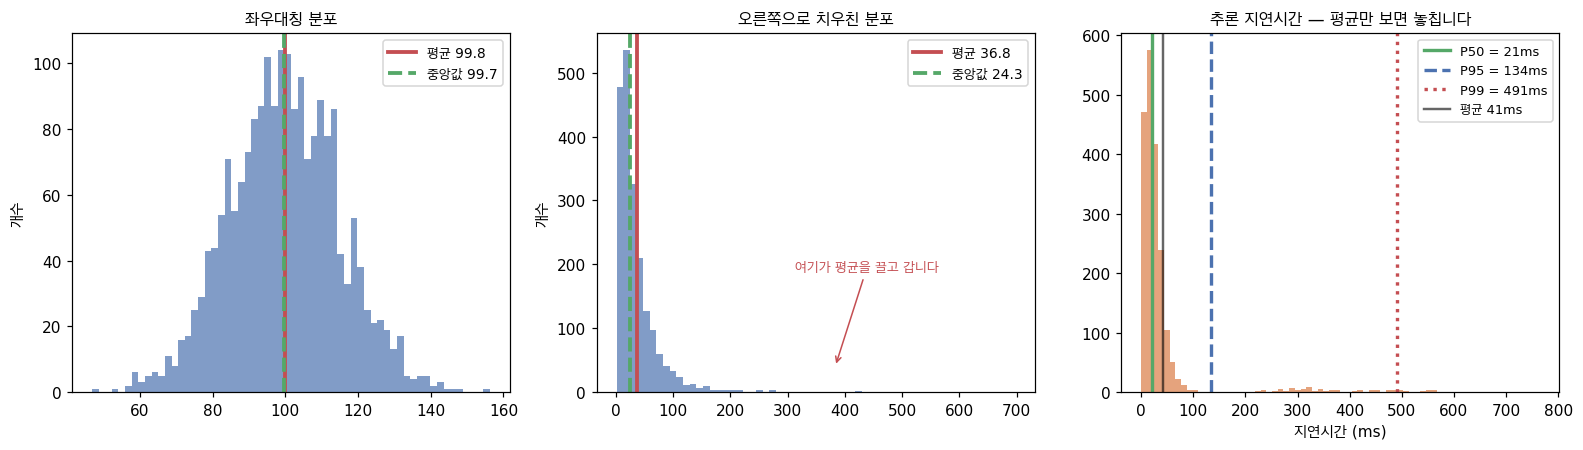

지연시간: 평균 41ms 인데 P99는 491ms 입니다.
  P99 / P50 = 23.5배
  '평균 응답 41ms'라고만 보고하면, 100명 중 1명이 겪는 491ms는 통째로 숨겨집니다.


In [5]:
rng = np.random.default_rng(1)
symmetric = rng.normal(100, 15, 2000)                      # 좌우대칭
right_skew = rng.lognormal(mean=3.2, sigma=0.9, size=2000)  # 오른쪽 꼬리 (소득형)
latency = np.concatenate([rng.gamma(2.0, 12, 1900), rng.gamma(9.0, 45, 100)])  # 꼬리 지연

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))

for ax, d, title in [(axes[0], symmetric, "좌우대칭 분포"),
                     (axes[1], right_skew, "오른쪽으로 치우친 분포")]:
    ax.hist(d, bins=60, color="#4c72b0", alpha=0.7)
    ax.axvline(d.mean(), color="#c44e52", lw=2.5, label=f"평균 {d.mean():.1f}")
    ax.axvline(np.median(d), color="#55a868", lw=2.5, ls="--", label=f"중앙값 {np.median(d):.1f}")
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_ylabel("개수")

axes[1].annotate("여기가 평균을 끌고 갑니다", xy=(right_skew.max() * 0.55, 40),
                 xytext=(right_skew.max() * 0.45, 190), fontsize=9, color="#c44e52",
                 arrowprops=dict(arrowstyle="->", color="#c44e52"))

ax = axes[2]
ax.hist(latency, bins=70, color="#dd8452", alpha=0.75)
for q, color, ls in [(50, "#55a868", "-"), (95, "#4c72b0", "--"), (99, "#c44e52", ":")]:
    v = np.percentile(latency, q)
    ax.axvline(v, color=color, lw=2.2, ls=ls, label=f"P{q} = {v:.0f}ms")
ax.axvline(latency.mean(), color="black", lw=1.6, alpha=0.6, label=f"평균 {latency.mean():.0f}ms")
ax.set_title("추론 지연시간 — 평균만 보면 놓칩니다", fontsize=11)
ax.legend(fontsize=8.5)
ax.set_xlabel("지연시간 (ms)")

plt.tight_layout()
plt.show()

print(f"지연시간: 평균 {latency.mean():.0f}ms 인데 P99는 {np.percentile(latency,99):.0f}ms 입니다.")
print(f"  P99 / P50 = {np.percentile(latency,99)/np.percentile(latency,50):.1f}배")
print(f"  '평균 응답 {latency.mean():.0f}ms'라고만 보고하면, 100명 중 1명이 겪는 "
      f"{np.percentile(latency,99):.0f}ms는 통째로 숨겨집니다.")

## 2️⃣ 상관 — 피어슨과 스피어만은 언제 갈라지나

두 변수가 **함께 움직이는 정도**를 재는 게 상관입니다. 대표적인 두 가지를 봅시다.

### 📐 피어슨 상관계수 — "직선 관계"를 잽니다

$$r = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum (x_i-\bar{x})^2}\sqrt{\sum (y_i-\bar{y})^2}}$$

−1에서 +1 사이 값이고, +1이면 완벽한 우상향 직선, −1이면 완벽한 우하향 직선, 0이면 **직선 관계가 없다**는 뜻입니다.

여기서 꼭 짚고 갈 게 있어요. **`r = 0`은 "관계가 없다"가 아니라 "직선 관계가 없다"입니다.**
`y = x²` 같은 완벽한 관계도 피어슨으로 재면 0이 나올 수 있습니다.

그리고 피어슨은 **이상치에 아주 약합니다.** 점 하나가 `r`을 0.1에서 0.9로 끌어올릴 수 있어요.
아래 코드에서 직접 확인해 보겠습니다.

### 📐 스피어만 순위 상관 — "단조 관계"를 잽니다

계산 방법이 재미있습니다. **값을 순위로 바꾼 다음, 그 순위에 피어슨을 적용**합니다. 그게 전부예요.

이렇게 하면 실제 값의 크기는 사라지고 **순서만** 남습니다.
그래서 `y = x³` 처럼 휘어 있지만 계속 증가하는 관계도 스피어만은 **정확히 1**로 잡아냅니다.
피어슨은 1보다 작게 나오고요.

### 🏭 그래서 언제 뭘 쓰나요

| | 피어슨 | 스피어만 |
| --- | --- | --- |
| 재는 것 | 직선 관계 | 단조(계속 증가/감소) 관계 |
| 데이터 | 연속형, 대략 정규 | 순위·평점 같은 순서형도 OK |
| 이상치 | **매우 취약** | 강건함 (순위로 바꾸니까) |
| 비선형 | 못 잡음 | 단조라면 잡음 |

실무 감각으로는, **일단 둘 다 계산해 보고 크게 다르면 산점도를 그려 보는 것**이 좋습니다.
둘이 갈라진다는 건 이상치가 있거나 관계가 휘어 있다는 신호거든요.

### ⚠️ 그리고 늘 나오는 그 이야기

**상관은 인과가 아닙니다.** 아이스크림 판매량과 익사 사고는 상관이 높지만
아이스크림이 익사를 부르는 게 아니라 **둘 다 여름에 늘어날 뿐**입니다.
모델 정확도와 파라미터 수도 상관이 있지만, 파라미터를 늘린다고 정확도가 저절로 오르지는 않죠(과적합).

In [6]:
def covariance(xs, ys, sample=True):
    n = len(xs)
    mx, my = mean(xs), mean(ys)
    total = sum((x - mx) * (y - my) for x, y in zip(xs, ys))
    return total / (n - 1) if sample else total / n

def pearson(xs, ys):
    sx, sy = stdev(xs), stdev(ys)
    if sx == 0 or sy == 0:
        return 0.0
    return covariance(xs, ys) / (sx * sy)

def rank(xs):
    # 동점은 평균 순위로 처리합니다 (스피어만의 표준 방식)
    order = sorted(range(len(xs)), key=lambda i: xs[i])
    ranks = [0.0] * len(xs)
    i = 0
    while i < len(order):
        j = i
        while j + 1 < len(order) and xs[order[j + 1]] == xs[order[i]]:
            j += 1
        avg = (i + j) / 2 + 1
        for k in range(i, j + 1):
            ranks[order[k]] = avg
        i = j + 1
    return ranks

def spearman(xs, ys):
    return pearson(rank(xs), rank(ys))

# 네 가지 상황을 만들어 두 계수를 비교합니다
rng = np.random.default_rng(4)
n = 60
x = np.linspace(1, 10, n)

cases = {
    "선형 관계":        (x, 2.0 * x + rng.normal(0, 1.5, n)),
    "단조하지만 휘었음": (x, x ** 3 + rng.normal(0, 20, n)),
    "이상치 하나":      (np.append(x[:-1], 30), np.append(rng.normal(5, 1.2, n - 1), 40)),
    "U자 (비단조)":     (x, (x - 5.5) ** 2 + rng.normal(0, 1.5, n)),
}

print(f"{'상황':<20}{'피어슨 r':>12}{'스피어만 ρ':>14}   해석")
print("-" * 78)
notes = ["둘 다 높습니다. 예상대로",
         "스피어만이 더 높습니다 — 휘어 있어도 순서는 완벽",
         "피어슨만 치솟습니다 — 점 하나에 속았습니다",
         "둘 다 0 근처 — 관계가 있는데도 못 잡습니다"]
for (name, (xv, yv)), note in zip(cases.items(), notes):
    print(f"{name:<20}{pearson(list(xv), list(yv)):>12.4f}{spearman(list(xv), list(yv)):>14.4f}   {note}")

print("\n[NumPy 대조]")
xv, yv = cases["선형 관계"]
print(f"  내 피어슨 {pearson(list(xv), list(yv)):.6f}  vs  np.corrcoef {np.corrcoef(xv, yv)[0,1]:.6f}")

상황                         피어슨 r        스피어만 ρ   해석
------------------------------------------------------------------------------
선형 관계                     0.9636        0.9678   둘 다 높습니다. 예상대로
단조하지만 휘었음                 0.9308        0.9757   스피어만이 더 높습니다 — 휘어 있어도 순서는 완벽
이상치 하나                    0.7215       -0.0800   피어슨만 치솟습니다 — 점 하나에 속았습니다
U자 (비단조)                  0.0086        0.0247   둘 다 0 근처 — 관계가 있는데도 못 잡습니다

[NumPy 대조]
  내 피어슨 0.963598  vs  np.corrcoef 0.963598


### 🖼️ 그림 2 — 같은 숫자 두 개(r, ρ)로는 절대 알 수 없는 것들

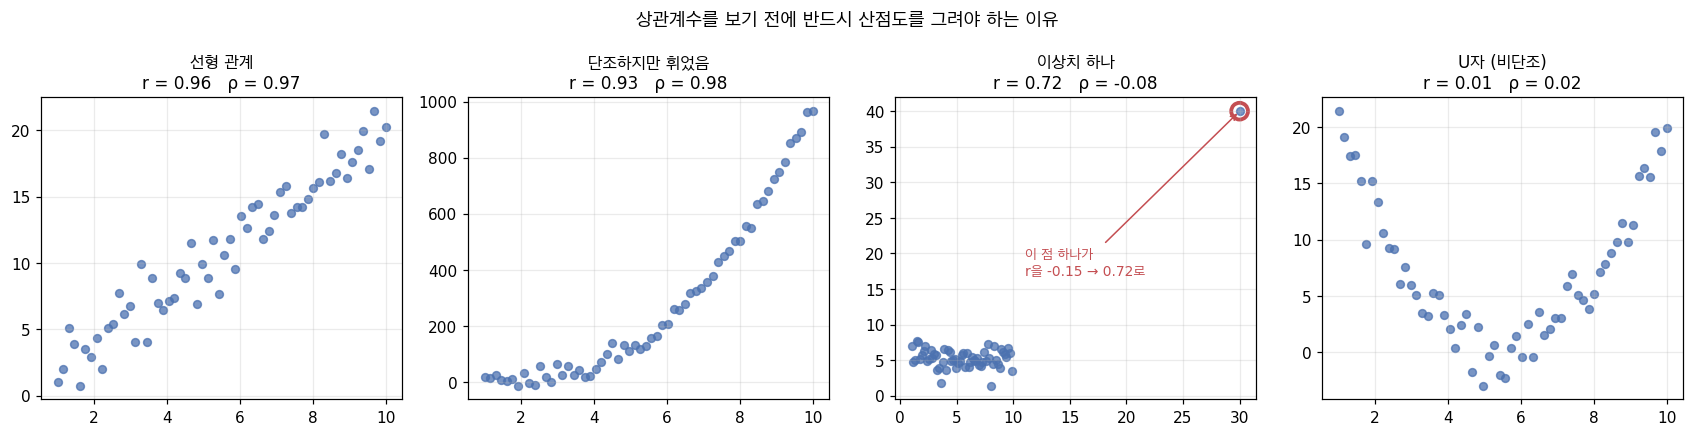

이상치 포함 : r = 0.7215
이상치 제외 : r = -0.1505   <- 사실은 아무 관계도 없었습니다
스피어만(포함): ρ = -0.0800   <- 순위로 보면 덜 속습니다


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(15.5, 4))
for ax, (name, (xv, yv)) in zip(axes, cases.items()):
    r, rho = pearson(list(xv), list(yv)), spearman(list(xv), list(yv))
    ax.scatter(xv, yv, s=26, color="#4c72b0", alpha=0.75)
    ax.set_title(f"{name}\nr = {r:.2f}   ρ = {rho:.2f}", fontsize=11)
    ax.grid(alpha=0.25)
    if name == "이상치 하나":
        ax.scatter([xv[-1]], [yv[-1]], s=120, facecolor="none", edgecolor="#c44e52", lw=2.5)
        r_without = pearson(list(xv[:-1]), list(yv[:-1]))
        ax.annotate(f"이 점 하나가\nr을 {r_without:.2f} → {r:.2f}로", xy=(xv[-1], yv[-1]),
                    xytext=(11, 17), fontsize=9, color="#c44e52",
                    arrowprops=dict(arrowstyle="->", color="#c44e52"))
plt.suptitle("상관계수를 보기 전에 반드시 산점도를 그려야 하는 이유", fontsize=12.5)
plt.tight_layout()
plt.show()

# 이상치를 빼면 r이 어떻게 변하는지 숫자로 확인
xv, yv = cases["이상치 하나"]
print(f"이상치 포함 : r = {pearson(list(xv), list(yv)):.4f}")
print(f"이상치 제외 : r = {pearson(list(xv[:-1]), list(yv[:-1])):.4f}   <- 사실은 아무 관계도 없었습니다")
print(f"스피어만(포함): ρ = {spearman(list(xv), list(yv)):.4f}   <- 순위로 보면 덜 속습니다")

## 3️⃣ 공분산 행렬 — PCA가 왜 하필 이걸 분해했는지

공분산은 두 변수가 **함께 움직이는 방향과 크기**입니다.

$$\text{Cov}(X,Y) = \frac{1}{n-1}\sum (x_i-\bar{x})(y_i-\bar{y})$$

양수면 같이 오르고, 음수면 하나가 오를 때 다른 하나가 내리고, 0이면 선형적인 동조가 없습니다.

특징이 `d`개면 공분산 행렬 `C`는 `d × d` 이고, `C[i][j] = Cov(특징 i, 특징 j)` 입니다.

```
C = | Var(x1)     Cov(x1,x2)  Cov(x1,x3) |
    | Cov(x2,x1)  Var(x2)     Cov(x2,x3) |
    | Cov(x3,x1)  Cov(x3,x2)  Var(x3)    |

성질:
  - 대칭입니다            C[i][j] = C[j][i]
  - 양의 준정부호입니다    모든 고유값 ≥ 0
  - 대각선 = 각 특징의 분산
  - 비대각선 = 특징 쌍의 공분산
```

### 🔑 여기서 PCA와 연결됩니다

3주차에 PCA가 **공분산 행렬을 고유분해**한다고 배웠는데, 그때는 "왜 하필 공분산 행렬이지?" 싶었을 수 있습니다.
이제 답이 보입니다. **공분산 행렬은 데이터의 모든 쌍별 선형 관계를 한 곳에 담고 있는 객체**이기 때문입니다.

- 고유벡터 → 분산이 가장 큰 방향들 (= 주성분)
- 고유값 → 그 방향이 설명하는 분산의 양

즉 "데이터가 가장 많이 퍼진 방향"을 찾는 문제가, 그대로 "공분산 행렬의 고유벡터를 찾는 문제"가 됩니다.

### 🔑 상관 행렬과의 관계도 한 줄입니다

**상관 행렬은 표준화된 변수(각자 표준편차로 나눈 것)의 공분산 행렬**입니다.
공분산은 단위에 따라 값이 제멋대로지만(cm·kg vs m·g), 상관은 [−1, 1]로 정규화되어 있어 서로 비교할 수 있어요.

In [8]:
def covariance_matrix(X):
    # X: 행이 샘플, 열이 특징
    d = len(X[0])
    cols = [[row[j] for row in X] for j in range(d)]
    return [[covariance(cols[i], cols[j]) for j in range(d)] for i in range(d)]

def correlation_matrix(X):
    d = len(X[0])
    cols = [[row[j] for row in X] for j in range(d)]
    return [[pearson(cols[i], cols[j]) for j in range(d)] for i in range(d)]

# 서로 다른 단위를 가진 특징 3개로 실험합니다
rng = np.random.default_rng(2)
n = 400
study_hours = rng.normal(5.0, 1.5, n)                             # 시간
score = 12 * study_hours + rng.normal(0, 8, n) + 20               # 점수(0~100)
shoe_size = rng.normal(260, 12, n)                                # mm, 관계 없음
X = np.column_stack([study_hours, score, shoe_size]).tolist()
names = ["공부시간(h)", "점수(점)", "발크기(mm)"]

C = np.array(covariance_matrix(X))
R = np.array(correlation_matrix(X))

print("공분산 행렬 (단위가 섞여 있어서 숫자 크기만으로는 비교가 안 됩니다)")
print(f"{'':>14}" + "".join(f"{nm:>14}" for nm in names))
for i, nm in enumerate(names):
    print(f"{nm:>14}" + "".join(f"{C[i][j]:>14.2f}" for j in range(3)))

print("\n상관 행렬 (모두 [-1, 1]로 정규화되어 서로 비교할 수 있습니다)")
print(f"{'':>14}" + "".join(f"{nm:>14}" for nm in names))
for i, nm in enumerate(names):
    print(f"{nm:>14}" + "".join(f"{R[i][j]:>14.3f}" for j in range(3)))

print(f"\nNumPy 대조: 최대 오차 {np.abs(C - np.cov(np.array(X).T)).max():.2e}")
print("\n관찰 두 가지")
print(f"  1) 공분산 값만 보면 '점수-발크기'가 {C[1][2]:.2f}, '공부시간-점수'가 {C[0][1]:.2f} 입니다.")
print("     그런데 단위(h·점 vs 점·mm)가 다르니 이 숫자들의 크기를 직접 비교하면 안 됩니다.")
print(f"  2) 상관으로 바꾸면 {R[1][2]:.3f} vs {R[0][1]:.3f} — 이제야 '하나는 무관, 하나는 강한 관계'로 읽힙니다.")

공분산 행렬 (단위가 섞여 있어서 숫자 크기만으로는 비교가 안 됩니다)
                     공부시간(h)         점수(점)       발크기(mm)
       공부시간(h)          2.29         27.62         -0.62
         점수(점)         27.62        397.22         -5.77
       발크기(mm)         -0.62         -5.77        147.44

상관 행렬 (모두 [-1, 1]로 정규화되어 서로 비교할 수 있습니다)
                     공부시간(h)         점수(점)       발크기(mm)
       공부시간(h)         1.000         0.915        -0.034
         점수(점)         0.915         1.000        -0.024
       발크기(mm)        -0.034        -0.024         1.000

NumPy 대조: 최대 오차 4.55e-13

관찰 두 가지
  1) 공분산 값만 보면 '점수-발크기'가 -5.77, '공부시간-점수'가 27.62 입니다.
     그런데 단위(h·점 vs 점·mm)가 다르니 이 숫자들의 크기를 직접 비교하면 안 됩니다.
  2) 상관으로 바꾸면 -0.024 vs 0.915 — 이제야 '하나는 무관, 하나는 강한 관계'로 읽힙니다.


In [9]:
# 🔑 공분산 행렬을 고유분해하면 그게 곧 PCA입니다. 직접 확인해 봅시다.
Xc = np.array(X) - np.array(X).mean(axis=0)          # 중심화
Cm = np.cov(Xc.T)
eigvals, eigvecs = np.linalg.eigh(Cm)                 # 대칭행렬용 고유분해
order = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[order], eigvecs[:, order]

print("공분산 행렬의 고유값 (= 각 주성분이 설명하는 분산의 양)")
total = eigvals.sum()
for i, ev in enumerate(eigvals):
    print(f"  PC{i+1}: 고유값 {ev:>10.2f}   설명 분산 비율 {ev/total*100:>6.2f}%")

print(f"\n첫 두 성분이 설명하는 비율: {eigvals[:2].sum()/total*100:.2f}%")
print("\n검증 1 — 고유값의 합 = 전체 분산 (대각합)")
print(f"  고유값 합 {eigvals.sum():.4f}  vs  대각합(trace) {np.trace(Cm):.4f}")
print("\n검증 2 — 모든 고유값이 0 이상 (양의 준정부호)")
print(f"  최소 고유값 = {eigvals.min():.4f}  ->  {eigvals.min() >= -1e-9}")
print("\n=> '분산이 가장 큰 방향 찾기' 문제가 '공분산 행렬의 고유벡터 찾기'와 같은 문제였던 겁니다.")

공분산 행렬의 고유값 (= 각 주성분이 설명하는 분산의 양)
  PC1: 고유값     399.28   설명 분산 비율  73.00%
  PC2: 고유값     147.31   설명 분산 비율  26.93%
  PC3: 고유값       0.37   설명 분산 비율   0.07%

첫 두 성분이 설명하는 비율: 99.93%

검증 1 — 고유값의 합 = 전체 분산 (대각합)
  고유값 합 546.9538  vs  대각합(trace) 546.9538

검증 2 — 모든 고유값이 0 이상 (양의 준정부호)
  최소 고유값 = 0.3697  ->  True

=> '분산이 가장 큰 방향 찾기' 문제가 '공분산 행렬의 고유벡터 찾기'와 같은 문제였던 겁니다.


### 🖼️ 그림 3 — 공분산 행렬과 상관 행렬을 나란히 보기

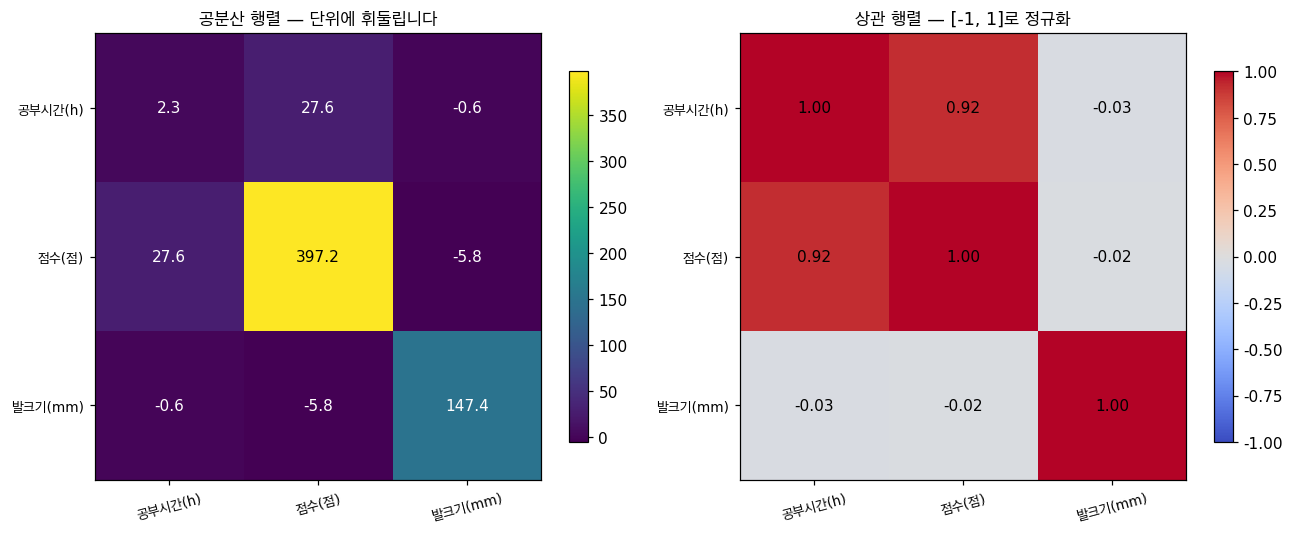

대각선은 각 특징의 분산(상관 행렬에서는 항상 1)이고, 비대각선이 관계를 나타냅니다.


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, M, title, fmt, cmap in [
    (ax1, C, "공분산 행렬 — 단위에 휘둘립니다", "{:.1f}", "viridis"),
    (ax2, R, "상관 행렬 — [-1, 1]로 정규화", "{:.2f}", "coolwarm"),
]:
    vmax = np.abs(M).max()
    im = ax.imshow(M, cmap=cmap, vmin=-vmax if cmap == "coolwarm" else None, vmax=vmax)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, fmt.format(M[i][j]), ha="center", va="center",
                    fontsize=10, color="white" if cmap == "viridis" and M[i][j] < vmax * 0.6 else "black")
    ax.set_xticks(range(3)); ax.set_xticklabels(names, fontsize=9, rotation=15)
    ax.set_yticks(range(3)); ax.set_yticklabels(names, fontsize=9)
    ax.set_title(title, fontsize=11.5)
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()
print("대각선은 각 특징의 분산(상관 행렬에서는 항상 1)이고, 비대각선이 관계를 나타냅니다.")

## 4️⃣ 가설검정 — p-value는 당신이 생각하는 그게 아닙니다

이제 이 레슨의 핵심으로 들어갑니다.

### 📐 기본 구조

가설검정은 **불확실성 속에서 판단하는 절차**입니다. 구조는 늘 똑같아요.

```
귀무가설 H0 : 기본 가정. 보통 "아무 효과 없다"
대립가설 H1 : 내가 보이고 싶은 것

예)
  H0: 모델 A와 모델 B의 정확도는 같다
  H1: 모델 B의 정확도가 더 높다
```

여기서 중요한 건 **출발점이 "차이가 없다"** 라는 겁니다.
법정으로 치면 무죄 추정이에요. 유죄(=차이가 있다)를 주장하려면 **증거를 가져와야** 합니다.

### ⚠️ p-value — 가장 많이 오해받는 개념

p-value가 뭐냐고 물으면 열에 아홉은 이렇게 답합니다.
*"귀무가설이 참일 확률이요."* — **틀렸습니다.** 그리고 이건 통계에서 가장 흔한 오해예요.

정확한 정의는 이렇습니다.

$$p\text{-value} = P(\text{이만큼 극단적인 데이터} \mid H_0\text{가 참})$$

조건이 어디에 걸려 있는지 보세요. **"H0가 참이라고 가정했을 때"** 입니다.
즉 p-value는 *가설*에 대한 확률이 아니라 *데이터*에 대한 확률이에요.

말로 풀면 이렇습니다.

> "차이가 정말 없다고 치자. 그런 세상에서 내가 관측한 것만큼(혹은 그보다 더) 극단적인
> 결과가 우연히 나올 확률은 얼마인가?"

이 확률이 아주 작다면(보통 0.05 미만), "우연이라고 보기엔 너무 이상한데?" 하면서 H0를 기각합니다.

```
p < α (보통 0.05)  →  H0 기각. "통계적으로 유의하다"
p ≥ α              →  H0를 기각하지 못함.
                      ⚠️ 이건 "H0가 참이다"라는 뜻이 아닙니다.
                         그냥 증거가 부족하다는 뜻입니다.
```

**"기각 실패"와 "H0 채택"은 다릅니다.** 증거 부족으로 무죄가 나온 것이지, 결백이 증명된 게 아니에요.

### ⚠️ 신뢰구간도 마찬가지로 오해받습니다

95% 신뢰구간을 이렇게 구합니다.

$$\bar{x} \pm z \cdot \frac{s}{\sqrt{n}} \qquad (z = 1.96)$$

그리고 "참값이 이 구간에 있을 확률이 95%"라고 읽는 분이 많은데, **이것도 틀렸습니다.**

정확한 의미는 **절차에 대한 보증**입니다.

> "이 실험을 100번 반복해서 매번 구간을 만들면, 그중 약 95개의 구간이 참값을 포함한다."

지금 내 앞에 있는 **이 구간 하나**는 참값을 포함하거나 안 하거나 둘 중 하나예요. 확률이 아니라 사실입니다.
95%는 **구간을 만드는 방법의 장기 성공률**입니다.

말장난 같지만 실제로 차이가 납니다. 아래에서 시뮬레이션으로 직접 보겠습니다.
구간 폭이 넓으면 불확실성이 크다는 뜻이고, 좁으면 추정이 정밀하다는 뜻입니다.
다만 **정밀한 것과 정확한 것은 다릅니다** — 데이터가 편향돼 있으면 좁은 구간이 엉뚱한 곳에 놓입니다.

In [11]:
# 먼저 정규분포와 t분포의 CDF를 밑바닥부터 만들어 둡니다.
# (이게 있어야 p-value를 계산할 수 있고, 이후 절에서 계속 씁니다)

def normal_cdf(z):
    # 오차함수 erf를 이용한 표준정규 CDF
    return 0.5 * (1.0 + math.erf(z / math.sqrt(2.0)))

def log_beta(a, b):
    return math.lgamma(a) + math.lgamma(b) - math.lgamma(a + b)

def betacf(a, b, x, itmax=300, eps=3e-14):
    # 정규화 불완전 베타함수용 연분수 (Lentz 알고리즘)
    tiny = 1e-300
    qab, qap, qam = a + b, a + 1.0, a - 1.0
    c = 1.0
    d = 1.0 - qab * x / qap
    if abs(d) < tiny:
        d = tiny
    d = 1.0 / d
    h = d
    for m in range(1, itmax + 1):
        m2 = 2 * m
        aa = m * (b - m) * x / ((qam + m2) * (a + m2))
        d = 1.0 + aa * d
        if abs(d) < tiny:
            d = tiny
        c = 1.0 + aa / c
        if abs(c) < tiny:
            c = tiny
        d = 1.0 / d
        h *= d * c
        aa = -(a + m) * (qab + m) * x / ((a + m2) * (qap + m2))
        d = 1.0 + aa * d
        if abs(d) < tiny:
            d = tiny
        c = 1.0 + aa / c
        if abs(c) < tiny:
            c = tiny
        d = 1.0 / d
        delta = d * c
        h *= delta
        if abs(delta - 1.0) < eps:
            break
    return h

def betainc(a, b, x):
    # 정규화 불완전 베타함수 I_x(a, b)
    if x <= 0:
        return 0.0
    if x >= 1:
        return 1.0
    front = math.exp(a * math.log(x) + b * math.log(1 - x) - log_beta(a, b))
    if x < (a + 1) / (a + b + 2):
        return front * betacf(a, b, x) / a
    return 1.0 - front * betacf(b, a, 1 - x) / b

def t_sf(t, df):
    # t분포의 오른쪽 꼬리 확률 P(T > t)
    x = df / (df + t * t)
    tail = 0.5 * betainc(df / 2.0, 0.5, x)
    return tail if t > 0 else 1.0 - tail

def t_two_sided_p(t, df):
    return 2.0 * t_sf(abs(t), df)

from scipy import stats as sps   # 검증용으로만 씁니다

print("직접 만든 분포 함수가 맞는지 scipy와 대조합니다")
print(f"{'입력':<22}{'내 구현':>16}{'scipy':>16}{'차이':>12}")
print("-" * 68)
for z in [-1.96, 0.0, 1.0, 2.58]:
    print(f"{'normal_cdf(' + str(z) + ')':<22}{normal_cdf(z):>16.10f}"
          f"{sps.norm.cdf(z):>16.10f}{abs(normal_cdf(z)-sps.norm.cdf(z)):>12.1e}")
for t, df in [(2.5, 9), (1.0, 30), (3.2, 4)]:
    mine, ref = t_two_sided_p(t, df), sps.t.sf(abs(t), df) * 2
    print(f"{'t양측p(' + str(t) + ', df=' + str(df) + ')':<22}{mine:>16.10f}{ref:>16.10f}{abs(mine-ref):>12.1e}")

직접 만든 분포 함수가 맞는지 scipy와 대조합니다
입력                                내 구현           scipy          차이
--------------------------------------------------------------------
normal_cdf(-1.96)         0.0249978951    0.0249978951     6.9e-18
normal_cdf(0.0)           0.5000000000    0.5000000000     0.0e+00
normal_cdf(1.0)           0.8413447461    0.8413447461     0.0e+00
normal_cdf(2.58)          0.9950599842    0.9950599842     1.1e-16
t양측p(2.5, df=9)           0.0338618277    0.0338618277     5.6e-17
t양측p(1.0, df=30)          0.3253086154    0.3253086154     4.3e-15
t양측p(3.2, df=4)           0.0329008106    0.0329008106     1.4e-17


### 🖼️ 그림 4 — p-value가 정확히 어느 면적인지 눈으로 보기

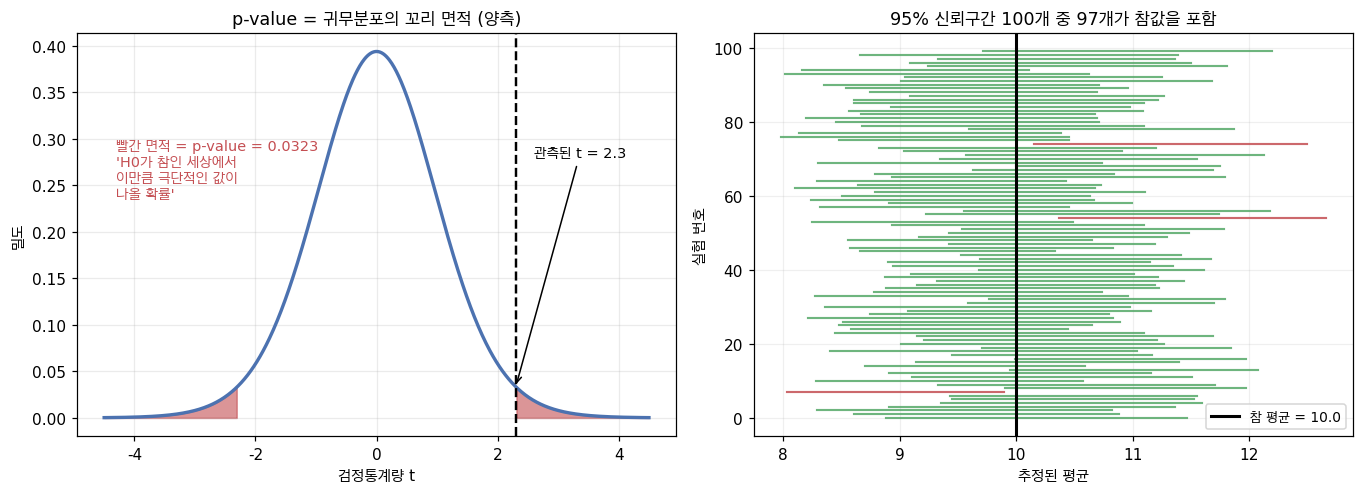

100번의 독립 실험 중 참값을 포함한 구간: 97개 (97%)

이게 '95% 신뢰'의 정확한 의미입니다.
  ⭕ '이 절차로 구간을 만들면 장기적으로 95%가 참값을 덮는다'
  ❌ '지금 이 구간 안에 참값이 있을 확률이 95%다'
  빨간 구간 3개는 참값을 놓쳤습니다. 그런데 실험자는 어느 게 빨간지 알 수 없습니다.


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

# 왼쪽: 귀무분포와 관측 통계량
df = 20
xs = np.linspace(-4.5, 4.5, 700)
pdf = sps.t.pdf(xs, df)
t_obs = 2.3
ax1.plot(xs, pdf, lw=2.2, color="#4c72b0")
ax1.fill_between(xs[xs >= t_obs], pdf[xs >= t_obs], color="#c44e52", alpha=0.6)
ax1.fill_between(xs[xs <= -t_obs], pdf[xs <= -t_obs], color="#c44e52", alpha=0.6)
ax1.axvline(t_obs, color="black", lw=1.6, ls="--")
ax1.annotate(f"관측된 t = {t_obs}", xy=(t_obs, sps.t.pdf(t_obs, df)),
             xytext=(2.6, 0.28), fontsize=9.5,
             arrowprops=dict(arrowstyle="->", color="black"))
p = t_two_sided_p(t_obs, df)
ax1.text(-4.3, 0.30, f"빨간 면적 = p-value = {p:.4f}\n"
                     f"'H0가 참인 세상에서\n이만큼 극단적인 값이\n나올 확률'",
         fontsize=9.5, color="#c44e52", va="top")
ax1.set_title("p-value = 귀무분포의 꼬리 면적 (양측)", fontsize=11.5)
ax1.set_xlabel("검정통계량 t"); ax1.set_ylabel("밀도")
ax1.grid(alpha=0.25)

# 오른쪽: 신뢰구간의 진짜 의미 — 100번 반복하면 95개가 참값을 덮습니다
rng = np.random.default_rng(3)
TRUE_MU = 10.0
n_exp, n_each = 100, 30
covered = 0
for i in range(n_exp):
    s = rng.normal(TRUE_MU, 3.0, n_each)
    se = s.std(ddof=1) / math.sqrt(n_each)
    half = sps.t.ppf(0.975, n_each - 1) * se
    lo, hi = s.mean() - half, s.mean() + half
    ok = lo <= TRUE_MU <= hi
    covered += ok
    ax2.plot([lo, hi], [i, i], color="#55a868" if ok else "#c44e52",
             lw=1.4, alpha=0.85)
ax2.axvline(TRUE_MU, color="black", lw=2, label=f"참 평균 = {TRUE_MU}")
ax2.set_title(f"95% 신뢰구간 100개 중 {covered}개가 참값을 포함", fontsize=11.5)
ax2.set_xlabel("추정된 평균"); ax2.set_ylabel("실험 번호")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f"100번의 독립 실험 중 참값을 포함한 구간: {covered}개 ({covered}%)")
print("\n이게 '95% 신뢰'의 정확한 의미입니다.")
print("  ⭕ '이 절차로 구간을 만들면 장기적으로 95%가 참값을 덮는다'")
print("  ❌ '지금 이 구간 안에 참값이 있을 확률이 95%다'")
print(f"  빨간 구간 {n_exp - covered}개는 참값을 놓쳤습니다. 그런데 실험자는 어느 게 빨간지 알 수 없습니다.")

## 5️⃣ t-검정 세 가지를 직접 구현하기

t-검정은 **평균을 비교**하는 검정입니다. 상황에 따라 세 가지 형태가 있어요.

### 📐 (1) 일표본 t-검정 — "이 평균이 특정 값과 다른가?"

$$t = \frac{\bar{x} - \mu_0}{s/\sqrt{n}}, \qquad df = n-1$$

분자는 **관측된 차이**, 분모는 **그 차이의 불확실성(표준오차)** 입니다.
즉 t는 **"차이가 잡음 몇 개분인가"** 를 재는 값이에요. t가 2라면 차이가 표준오차의 2배쯤 된다는 뜻이고,
그 정도면 우연으로 보기 어려워지기 시작합니다.

### 📐 (2) 이표본 t-검정 (독립) — "두 그룹의 평균이 다른가?"

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{s_1^2/n_1 + s_2^2/n_2}}$$

이게 **Welch의 t-검정**입니다. 두 그룹의 분산이 같다고 **가정하지 않아요.**
특별한 이유가 없다면 항상 Welch를 쓰는 게 안전합니다. 등분산 가정은 깨지기 쉽거든요.

### 📐 (3) 대응표본 t-검정 — ML에서 가장 많이 쓰게 될 형태

측정값이 **짝을 이룰 때** 씁니다. 예를 들어 같은 교차검증 폴드에서 모델 A와 B를 각각 평가했다면,
`(폴드1의 A점수, 폴드1의 B점수)` 처럼 짝이 생기죠.

방법은 간단합니다. **각 짝의 차이 `d_i = x_i − y_i` 를 구한 다음, 그 차이들에 일표본 t-검정을 적용**합니다.

왜 이게 더 좋을까요? **폴드마다 난이도가 다른 데서 오는 변동을 상쇄**하기 때문입니다.
어려운 폴드에서는 두 모델 다 점수가 낮을 텐데, 차이를 먼저 계산하면 그 공통 변동이 사라집니다.
결과적으로 **같은 데이터로 훨씬 예민하게** 차이를 잡아낼 수 있어요. 7절에서 숫자로 확인합니다.

In [13]:
def one_sample_ttest(xs, mu0=0.0):
    n = len(xs)
    t = (mean(xs) - mu0) / (stdev(xs) / math.sqrt(n))
    df = n - 1
    return t, df, t_two_sided_p(t, df)

def welch_ttest(xs, ys):
    n1, n2 = len(xs), len(ys)
    v1, v2 = variance(xs), variance(ys)
    se = math.sqrt(v1 / n1 + v2 / n2)
    t = (mean(xs) - mean(ys)) / se
    # Welch-Satterthwaite 자유도 (정수가 아닙니다)
    df = (v1 / n1 + v2 / n2) ** 2 / ((v1 / n1) ** 2 / (n1 - 1) + (v2 / n2) ** 2 / (n2 - 1))
    return t, df, t_two_sided_p(t, df)

def paired_ttest(xs, ys):
    d = [x - y for x, y in zip(xs, ys)]
    return one_sample_ttest(d, 0.0)

def confidence_interval(xs, conf=0.95):
    n = len(xs)
    se = stdev(xs) / math.sqrt(n)
    # t 임계값을 이분 탐색으로 찾습니다 (scipy 없이)
    target = (1 - conf) / 2
    lo, hi = 0.0, 100.0
    for _ in range(200):
        mid = (lo + hi) / 2
        if t_sf(mid, n - 1) > target:
            lo = mid
        else:
            hi = mid
    tcrit = (lo + hi) / 2
    m = mean(xs)
    return m - tcrit * se, m + tcrit * se

rng = np.random.default_rng(11)
group_a = list(rng.normal(0.870, 0.020, 12))
group_b = list(rng.normal(0.889, 0.024, 12))

print("[1] 일표본 t-검정 — '모델 A의 정확도가 0.85와 다른가?'")
t, df, p = one_sample_ttest(group_a, 0.85)
print(f"    표본평균 {mean(group_a):.4f},  t = {t:.4f},  df = {df},  p = {p:.6f}")
print(f"    -> p {'<' if p < 0.05 else '>='} 0.05 이므로 H0를 {'기각합니다' if p < 0.05 else '기각하지 못합니다'}")

print("\n[2] Welch 이표본 t-검정 — 'A와 B의 평균이 다른가?' (독립이라고 가정)")
t, df, p = welch_ttest(group_a, group_b)
print(f"    A 평균 {mean(group_a):.4f}, B 평균 {mean(group_b):.4f}")
print(f"    t = {t:.4f},  df = {df:.2f},  p = {p:.6f}")

print("\n[3] 대응표본 t-검정 — 같은 폴드에서 나온 짝이라고 보면")
t, df, p = paired_ttest(group_b, group_a)
print(f"    평균 차이 {mean([b - a for a, b in zip(group_a, group_b)]):.4f}")
print(f"    t = {t:.4f},  df = {df},  p = {p:.6f}")

lo, hi = confidence_interval(group_a)
print(f"\n모델 A 정확도의 95% 신뢰구간: [{lo:.4f}, {hi:.4f}]")

print("\n[scipy 대조]")
t1, p1 = sps.ttest_1samp(group_a, 0.85)
t2, p2 = sps.ttest_ind(group_a, group_b, equal_var=False)
t3, p3 = sps.ttest_rel(group_b, group_a)
print(f"  일표본  : 내 p={one_sample_ttest(group_a, 0.85)[2]:.8f}  scipy p={p1:.8f}")
print(f"  Welch   : 내 p={welch_ttest(group_a, group_b)[2]:.8f}  scipy p={p2:.8f}")
print(f"  대응표본: 내 p={paired_ttest(group_b, group_a)[2]:.8f}  scipy p={p3:.8f}")

[1] 일표본 t-검정 — '모델 A의 정확도가 0.85와 다른가?'
    표본평균 0.8736,  t = 4.2164,  df = 11,  p = 0.001445
    -> p < 0.05 이므로 H0를 기각합니다

[2] Welch 이표본 t-검정 — 'A와 B의 평균이 다른가?' (독립이라고 가정)
    A 평균 0.8736, B 평균 0.8872
    t = -1.8220,  df = 21.69,  p = 0.082273

[3] 대응표본 t-검정 — 같은 폴드에서 나온 짝이라고 보면
    평균 차이 0.0136
    t = 2.0925,  df = 11,  p = 0.060377

모델 A 정확도의 95% 신뢰구간: [0.8613, 0.8859]

[scipy 대조]
  일표본  : 내 p=0.00144518  scipy p=0.00144518
  Welch   : 내 p=0.08227318  scipy p=0.08227318
  대응표본: 내 p=0.06037724  scipy p=0.06037724


## 6️⃣ 카이제곱 검정 — 범주형 데이터를 위한 도구

t-검정은 평균을 비교하지만, 세상에는 평균이 없는 데이터도 있습니다.
"긍정/부정/중립" 같은 **범주**요. 이럴 때 쓰는 게 카이제곱 검정입니다.

질문은 이렇습니다. **"관측된 빈도가 기대 빈도와 얼마나 다른가?"**

$$\chi^2 = \sum \frac{(\text{관측} - \text{기대})^2}{\text{기대}}$$

식을 뜯어보면 직관적입니다. 분자는 **어긋난 정도를 제곱**한 것이고,
분모로 기대값을 나누는 건 **규모 보정**입니다.
기대가 1000인데 20 어긋난 것과, 기대가 10인데 20 어긋난 건 심각도가 전혀 다르니까요.

```
예) 언어모델의 출력 분포가 학습 분포와 맞는가?

범주       관측    기대
긍정        120     100
부정         80     100

χ² = (120-100)²/100 + (80-100)²/100 = 4 + 4 = 8
자유도 1에서 χ² = 8 이면 p < 0.005 → 차이가 유의합니다
```

🏭 실무에서는 **데이터 드리프트 탐지**에 자주 씁니다.
프로덕션에 들어오는 입력의 범주 분포가 학습 때와 달라졌는지를 이걸로 감시하는 거죠.

In [14]:
def gammainc_lower_reg(s, x, itmax=500, eps=1e-14):
    # 정규화 하부 불완전 감마함수 P(s, x) — 카이제곱 CDF에 필요합니다
    if x <= 0:
        return 0.0
    if x < s + 1.0:
        # 급수 전개
        ap, total, delta = s, 1.0 / s, 1.0 / s
        for _ in range(itmax):
            ap += 1
            delta *= x / ap
            total += delta
            if abs(delta) < abs(total) * eps:
                break
        return total * math.exp(-x + s * math.log(x) - math.lgamma(s))
    # 연분수 전개 (상부를 구해 1에서 뺍니다)
    tiny = 1e-300
    b, c = x + 1.0 - s, 1.0 / tiny
    d = 1.0 / b
    h = d
    for i in range(1, itmax + 1):
        an = -i * (i - s)
        b += 2.0
        d = an * d + b
        if abs(d) < tiny:
            d = tiny
        c = b + an / c
        if abs(c) < tiny:
            c = tiny
        d = 1.0 / d
        delta = d * c
        h *= delta
        if abs(delta - 1.0) < eps:
            break
    q = math.exp(-x + s * math.log(x) - math.lgamma(s)) * h
    return 1.0 - q

def chi2_sf(x, df):
    return 1.0 - gammainc_lower_reg(df / 2.0, x / 2.0)

def chi_squared_test(observed, expected=None):
    if expected is None:
        total = sum(observed)
        expected = [total / len(observed)] * len(observed)
    stat = sum((o - e) ** 2 / e for o, e in zip(observed, expected))
    df = len(observed) - 1
    return stat, df, chi2_sf(stat, df)

obs = [120, 80]
exp = [100, 100]
stat, df, p = chi_squared_test(obs, exp)
print(f"관측 {obs}, 기대 {exp}")
print(f"  χ² = {stat:.4f},  df = {df},  p = {p:.6f}")
print(f"  scipy 대조: {sps.chisquare(obs, exp).pvalue:.6f}")

print("\n[🏭 실무 예 — 데이터 드리프트 감시]")
train_dist = [0.50, 0.30, 0.15, 0.05]           # 학습 데이터의 클래스 비율
labels = ["문의", "불만", "칭찬", "기타"]
n_prod = 2000
rng = np.random.default_rng(13)

for tag, real_dist in [("드리프트 없음", [0.50, 0.30, 0.15, 0.05]),
                       ("드리프트 발생", [0.42, 0.38, 0.14, 0.06])]:
    counts = rng.multinomial(n_prod, real_dist)
    expected = [n_prod * p for p in train_dist]
    stat, df, p = chi_squared_test(list(counts), expected)
    verdict = "🚨 분포가 바뀌었습니다" if p < 0.05 else "✅ 학습 분포와 일관됩니다"
    print(f"\n  [{tag}]")
    print(f"    관측 {dict(zip(labels, counts))}")
    print(f"    기대 {dict(zip(labels, [int(e) for e in expected]))}")
    print(f"    χ² = {stat:.3f}, p = {p:.6f}  ->  {verdict}")

관측 [120, 80], 기대 [100, 100]
  χ² = 8.0000,  df = 1,  p = 0.004678
  scipy 대조: 0.004678

[🏭 실무 예 — 데이터 드리프트 감시]

  [드리프트 없음]
    관측 {'문의': 989, '불만': 633, '칭찬': 293, '기타': 85}
    기대 {'문의': 1000, '불만': 600, '칭찬': 300, '기타': 100}
    χ² = 4.349, p = 0.226130  ->  ✅ 학습 분포와 일관됩니다

  [드리프트 발생]
    관측 {'문의': 821, '불만': 783, '칭찬': 269, '기타': 127}
    기대 {'문의': 1000, '불만': 600, '칭찬': 300, '기타': 100}
    χ² = 98.349, p = 0.000000  ->  🚨 분포가 바뀌었습니다


## 7️⃣ 🔨 모델 A vs B — 제대로 비교하는 절차

이제 0절의 문제로 돌아갑니다. 모델 두 개를 **제대로** 비교하려면 어떻게 해야 할까요?

먼저 알아둘 게 있습니다. **ML 모델 비교는 웹 A/B 테스트와 다릅니다.** 고유한 함정들이 있어요.

```
1. 같은 테스트셋      두 모델을 반드시 동일한 데이터로 평가해야 합니다.
                      다른 테스트셋에서 나온 점수 비교는 의미가 없습니다.

2. 여러 지표          정확도 하나로는 부족합니다. 정밀도, 재현율, F1,
                      지연시간, 공정성 지표까지 함께 봐야 합니다.

3. 분산 추정          점 추정치만 보지 말고 교차검증이나 부트스트랩으로
                      그 지표의 분산까지 추정해야 합니다.

4. 데이터 누수        모델 선택에 테스트셋을 썼다면 그 비교는 이미 편향됐습니다.
                      최종 테스트셋은 따로 떼어 두세요.
```

### 📐 절차

```
1. 지표와 유의수준(α = 0.05)을 먼저 정합니다   ← "먼저"가 중요합니다
2. 두 모델을 같은 k-폴드 분할에서 돌립니다
3. 짝지어진 점수를 모읍니다: [(a1,b1), (a2,b2), ..., (ak,bk)]
4. 차이를 계산합니다: d_i = b_i - a_i
5. 차이에 대응표본 t-검정을 적용합니다
6. 평균 차이가 0과 유의하게 다른지 확인합니다
7. 평균 차이의 신뢰구간을 구합니다
8. 효과 크기(Cohen's d)로 실질적 의미를 판단합니다
```

7번과 8번을 빠뜨리는 경우가 정말 많은데, **사실 의사결정에는 이 둘이 더 중요합니다.**
p-value는 "차이가 있냐 없냐"만 알려주고, **"얼마나 차이 나냐"는 신뢰구간과 효과 크기가 알려주거든요.**

아래에서 **대응표본이 왜 독립표본보다 예민한지**도 함께 확인해 보겠습니다.

In [15]:
def cohens_d(xs, ys):
    n1, n2 = len(xs), len(ys)
    v1, v2 = variance(xs), variance(ys)
    pooled = math.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
    return (mean(xs) - mean(ys)) / pooled

def compare_models(scores_a, scores_b, alpha=0.05, name_a="A", name_b="B"):
    d = [b - a for a, b in zip(scores_a, scores_b)]
    t, df, p = one_sample_ttest(d, 0.0)
    lo, hi = confidence_interval(d)
    eff = mean(d) / stdev(d)          # 대응 설계의 효과 크기
    print(f"  {name_a} 평균 {mean(scores_a):.4f} (±{stdev(scores_a):.4f})")
    print(f"  {name_b} 평균 {mean(scores_b):.4f} (±{stdev(scores_b):.4f})")
    print(f"  평균 차이 = {mean(d):+.4f}")
    print(f"  대응표본 t = {t:.3f}, df = {df}, p = {p:.5f}")
    print(f"  차이의 95% 신뢰구간 = [{lo:+.4f}, {hi:+.4f}]"
          f"  -> 0을 {'포함하지 않습니다' if lo > 0 or hi < 0 else '포함합니다'}")
    print(f"  효과 크기 = {eff:.3f}")
    print(f"  판정: {'✅ 유의한 차이' if p < alpha else '❌ 유의하지 않음 (증거 부족)'}")
    return p

# 10-폴드 교차검증 시뮬레이션.
# 핵심: 폴드마다 '난이도'가 있어서 두 모델의 점수가 같이 오르내립니다.
rng = np.random.default_rng(21)
K = 10
fold_difficulty = rng.normal(0, 0.035, K)      # 폴드 공통 변동 (큽니다)
true_gain = 0.012                               # B가 진짜로 나은 정도 (작습니다)

scores_a = [0.86 + fold_difficulty[i] + rng.normal(0, 0.004) for i in range(K)]
scores_b = [0.86 + true_gain + fold_difficulty[i] + rng.normal(0, 0.004) for i in range(K)]

print("폴드별 점수")
print(f"{'폴드':>6}{'모델 A':>12}{'모델 B':>12}{'차이 B-A':>12}")
print("-" * 44)
for i, (a, b) in enumerate(zip(scores_a, scores_b)):
    print(f"{i+1:>6}{a:>12.4f}{b:>12.4f}{b-a:>+12.4f}")

print("\n=== 방법 1: 독립 이표본 검정 (짝을 무시) ===")
t, df, p_ind = welch_ttest(scores_b, scores_a)
print(f"  t = {t:.3f}, df = {df:.1f}, p = {p_ind:.5f}  -> "
      f"{'유의' if p_ind < 0.05 else '유의하지 않음'}")

print("\n=== 방법 2: 대응표본 검정 (짝을 활용) ===")
p_paired = compare_models(scores_a, scores_b)

print(f"\n💡 같은 데이터인데 p가 {p_ind:.4f} → {p_paired:.6f} 로 바뀌었습니다.")
print("   폴드 난이도라는 공통 변동을 차이 계산으로 지워버렸기 때문입니다.")
print("   짝지어진 데이터에서 독립 검정을 쓰면, 있는 신호도 못 찾습니다.")

폴드별 점수
    폴드        모델 A        모델 B      차이 B-A
--------------------------------------------
     1      0.8749      0.8871     +0.0122
     2      0.9154      0.9257     +0.0103
     3      0.7907      0.8062     +0.0155
     4      0.9127      0.9310     +0.0183
     5      0.8646      0.8698     +0.0052
     6      0.8359      0.8476     +0.0117
     7      0.8406      0.8444     +0.0038
     8      0.8269      0.8404     +0.0135
     9      0.8481      0.8611     +0.0130
    10      0.8943      0.9031     +0.0087

=== 방법 1: 독립 이표본 검정 (짝을 무시) ===
  t = 0.629, df = 18.0, p = 0.53737  -> 유의하지 않음

=== 방법 2: 대응표본 검정 (짝을 활용) ===
  A 평균 0.8604 (±0.0398)
  B 평균 0.8716 (±0.0400)
  평균 차이 = +0.0112
  대응표본 t = 8.006, df = 9, p = 0.00002
  차이의 95% 신뢰구간 = [+0.0080, +0.0144]  -> 0을 포함하지 않습니다
  효과 크기 = 2.532
  판정: ✅ 유의한 차이

💡 같은 데이터인데 p가 0.5374 → 0.000022 로 바뀌었습니다.
   폴드 난이도라는 공통 변동을 차이 계산으로 지워버렸기 때문입니다.
   짝지어진 데이터에서 독립 검정을 쓰면, 있는 신호도 못 찾습니다.


### 🖼️ 그림 5 — 짝을 활용하면 왜 더 잘 보이는가

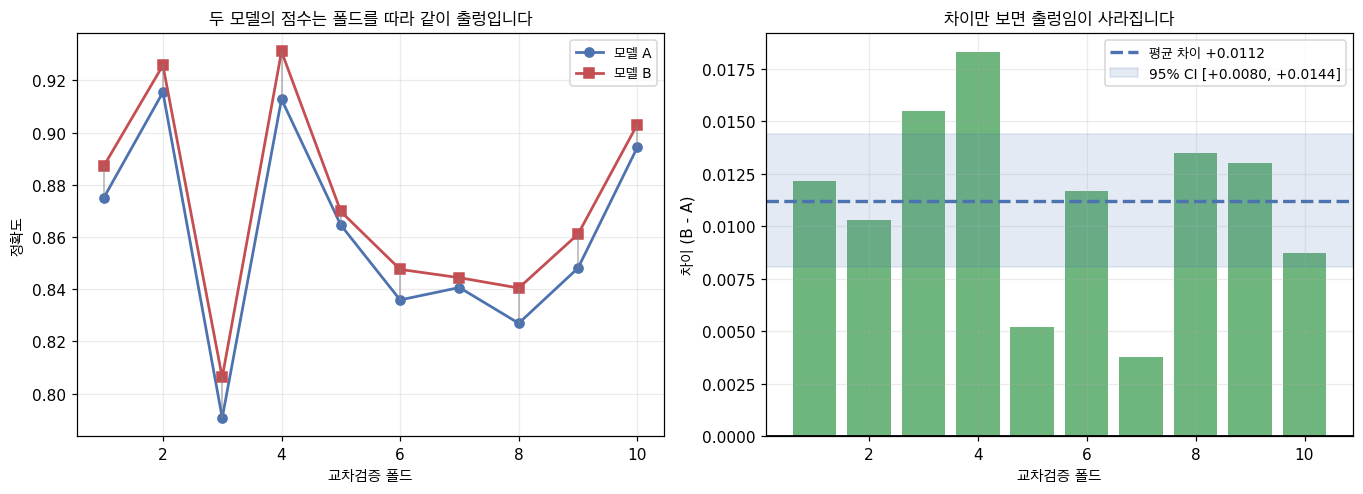

A 점수의 표준편차      : 0.03982
B 점수의 표준편차      : 0.03996
차이(B-A)의 표준편차   : 0.00443   <- 한 자릿수 작습니다

왼쪽 그림에서 두 선은 나란히 움직입니다. 이 '나란함'이 바로 폴드 난이도예요.
차이를 계산하면 그게 통째로 상쇄되고, 순수한 모델 차이만 남습니다.


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

idx = np.arange(1, K + 1)
ax1.plot(idx, scores_a, "o-", color="#4c72b0", lw=1.8, label="모델 A")
ax1.plot(idx, scores_b, "s-", color="#c44e52", lw=1.8, label="모델 B")
for i in range(K):
    ax1.plot([idx[i], idx[i]], [scores_a[i], scores_b[i]], color="gray", lw=1, alpha=0.6)
ax1.set_xlabel("교차검증 폴드"); ax1.set_ylabel("정확도")
ax1.set_title("두 모델의 점수는 폴드를 따라 같이 출렁입니다", fontsize=11.5)
ax1.legend(fontsize=9); ax1.grid(alpha=0.25)

d = np.array(scores_b) - np.array(scores_a)
ax2.bar(idx, d, color=["#55a868" if v > 0 else "#c44e52" for v in d], alpha=0.85)
ax2.axhline(0, color="black", lw=1.2)
ax2.axhline(d.mean(), color="#4c72b0", lw=2.2, ls="--", label=f"평균 차이 {d.mean():+.4f}")
lo, hi = confidence_interval(list(d))
ax2.axhspan(lo, hi, color="#4c72b0", alpha=0.15, label=f"95% CI [{lo:+.4f}, {hi:+.4f}]")
ax2.set_xlabel("교차검증 폴드"); ax2.set_ylabel("차이 (B - A)")
ax2.set_title("차이만 보면 출렁임이 사라집니다", fontsize=11.5)
ax2.legend(fontsize=9); ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"A 점수의 표준편차      : {np.std(scores_a, ddof=1):.5f}")
print(f"B 점수의 표준편차      : {np.std(scores_b, ddof=1):.5f}")
print(f"차이(B-A)의 표준편차   : {d.std(ddof=1):.5f}   <- 한 자릿수 작습니다")
print("\n왼쪽 그림에서 두 선은 나란히 움직입니다. 이 '나란함'이 바로 폴드 난이도예요.")
print("차이를 계산하면 그게 통째로 상쇄되고, 순수한 모델 차이만 남습니다.")

## 8️⃣ 통계적 유의성 ≠ 실질적 유의성

여기가 실무에서 제일 중요한 절입니다.

결과가 **통계적으로는 유의한데 실질적으로는 아무 의미가 없을** 수 있습니다.
그리고 이건 예외 상황이 아니라, **데이터가 충분히 많으면 거의 항상 일어나는 일**이에요.

```
예)
  모델 A 정확도: 0.9234
  모델 B 정확도: 0.9237
  테스트 샘플 수: 1,000,000
  p-value = 0.001

통계적으로 유의한가?  예.
실질적으로 유의한가?  0.03% 개선을 위해 새 모델을 배포하고,
                      모니터링을 붙이고, 롤백 계획을 세울 가치가 있나요?
```

왜 이런 일이 생기냐면, **p-value는 표본 크기에 의존하기 때문**입니다.
`n`이 커지면 표준오차 `s/√n`이 작아지고, 그러면 아무리 작은 차이도 t값이 커집니다.
**n을 무한히 늘리면 0이 아닌 모든 차이는 결국 유의해집니다.**

### 📐 그래서 효과 크기를 함께 봅니다

효과 크기는 **표본 크기와 무관하게 차이의 크기 자체**를 재는 지표입니다.

$$\text{Cohen's } d = \frac{\bar{x}_1 - \bar{x}_2}{s_{\text{pooled}}}$$

"차이가 표준편차의 몇 배인가"를 재는 거죠. 관례적인 해석은 이렇습니다.

| d | 해석 |
| --- | --- |
| 0.2 | 작은 효과 |
| 0.5 | 중간 효과 |
| 0.8 | 큰 효과 |

> 🏭 **실무 원칙: p-value와 효과 크기를 항상 함께 보고하세요.**
> **p-value는 "차이가 진짜인가"** 를 알려주고,
> **효과 크기는 "그 차이가 신경 쓸 만한가"** 를 알려줍니다. 둘 다 필요합니다.

In [17]:
# 표본 크기만 바꿔가며 같은 크기의 차이를 검정해 봅니다.
# 차이는 항상 0.0003 (0.03%p)로 고정합니다 — 실무적으로는 무의미한 수준입니다.

rng = np.random.default_rng(31)
TINY_DIFF = 0.0003
SD = 0.02

print(f"두 모델의 진짜 차이 = {TINY_DIFF} (0.03%p). 실무적으로는 무의미한 수준입니다.")
header = f"{'표본 크기':>12}{'관측 차이':>14}{'p-value':>14}{'유의?':>10}" + f"{chr(34) + 'Cohen' + chr(39) + 's d' + chr(34):>14}" + f"{'해석':>12}"
print()
print(header)
print("-" * 78)
for n in [30, 100, 1000, 10_000, 100_000, 1_000_000]:
    a = rng.normal(0.9234, SD, n)
    b = rng.normal(0.9234 + TINY_DIFF, SD, n)
    t, df, p = welch_ttest(list(a), list(b))
    d = abs(cohens_d(list(a), list(b)))
    sig = "✅ 유의" if p < 0.05 else "❌"
    interp = "무시할 수준" if d < 0.2 else ("작음" if d < 0.5 else "중간 이상")
    print(f"{n:>12,}{b.mean()-a.mean():>+14.6f}{p:>14.6f}{sig:>10}{d:>14.4f}{interp:>12}")

print("\n=> n이 커지면 p-value는 0으로 수렴하지만, 효과 크기는 그대로입니다.")
print("   p-value는 '차이를 탐지할 수 있는가'를 재고, 효과 크기는 '차이가 큰가'를 잽니다.")
print("   두 질문은 다릅니다. 그래서 둘 다 봐야 합니다.")

두 모델의 진짜 차이 = 0.0003 (0.03%p). 실무적으로는 무의미한 수준입니다.

       표본 크기         관측 차이       p-value       유의?   "Cohen's d"          해석
------------------------------------------------------------------------------
          30     -0.004727      0.292396         ❌        0.2743          작음
         100     -0.000594      0.820259         ❌        0.0322      무시할 수준
       1,000     -0.000584      0.528113         ❌        0.0282      무시할 수준
      10,000     -0.000124      0.662504         ❌        0.0062      무시할 수준
     100,000     +0.000241      0.006953      ✅ 유의        0.0121      무시할 수준
   1,000,000     +0.000263      0.000000      ✅ 유의        0.0132      무시할 수준

=> n이 커지면 p-value는 0으로 수렴하지만, 효과 크기는 그대로입니다.
   p-value는 '차이를 탐지할 수 있는가'를 재고, 효과 크기는 '차이가 큰가'를 잽니다.
   두 질문은 다릅니다. 그래서 둘 다 봐야 합니다.


### 🖼️ 그림 6 — n을 키우면 무엇이 변하고 무엇이 안 변하는가

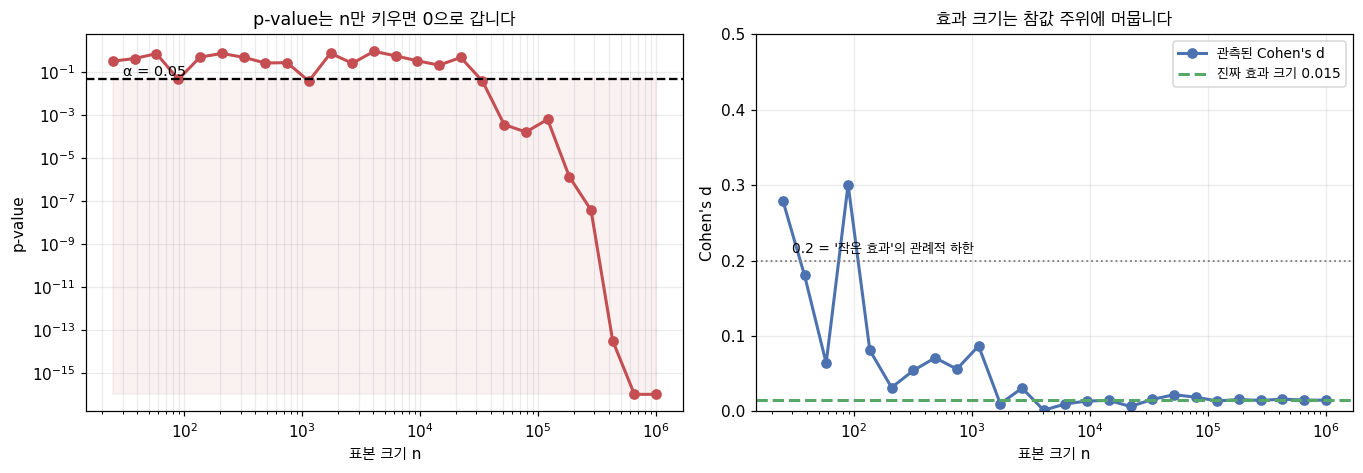

왼쪽: n을 늘리기만 하면 어떤 미세한 차이든 '통계적으로 유의'해집니다.
오른쪽: 그런데 효과 크기는 0.015 근처에 그대로 있습니다 — '작은 효과' 기준의 1/13 수준입니다.

🏭 그래서 논문이나 리포트에 '유의미한 개선(p<0.001)'만 적혀 있으면 의심해야 합니다.
   반드시 '얼마나' 개선됐는지, 표본이 얼마나 컸는지를 함께 확인하세요.


In [18]:
rng = np.random.default_rng(32)
ns = np.unique(np.logspace(1.4, 6, 26).astype(int))
ps, ds = [], []
for n in ns:
    a = rng.normal(0.9234, SD, n)
    b = rng.normal(0.9234 + TINY_DIFF, SD, n)
    _, _, p = welch_ttest(list(a), list(b))
    ps.append(max(p, 1e-16))
    ds.append(abs(cohens_d(list(a), list(b))))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax1.loglog(ns, ps, "o-", color="#c44e52", lw=2)
ax1.axhline(0.05, color="black", ls="--", lw=1.5)
ax1.text(ns[0] * 1.2, 0.065, "α = 0.05", fontsize=9.5)
ax1.fill_between(ns, 1e-16, 0.05, color="#c44e52", alpha=0.08)
ax1.set_xlabel("표본 크기 n"); ax1.set_ylabel("p-value")
ax1.set_title("p-value는 n만 키우면 0으로 갑니다", fontsize=11.5)
ax1.grid(alpha=0.25, which="both")

ax2.semilogx(ns, ds, "o-", color="#4c72b0", lw=2, label="관측된 Cohen's d")
ax2.axhline(TINY_DIFF / SD, color="#55a868", lw=2, ls="--",
            label=f"진짜 효과 크기 {TINY_DIFF/SD:.3f}")
ax2.axhline(0.2, color="gray", lw=1.2, ls=":")
ax2.text(ns[0] * 1.2, 0.21, "0.2 = '작은 효과'의 관례적 하한", fontsize=9)
ax2.set_xlabel("표본 크기 n"); ax2.set_ylabel("Cohen's d")
ax2.set_ylim(0, 0.5)
ax2.set_title("효과 크기는 참값 주위에 머뭅니다", fontsize=11.5)
ax2.legend(fontsize=9); ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("왼쪽: n을 늘리기만 하면 어떤 미세한 차이든 '통계적으로 유의'해집니다.")
print("오른쪽: 그런데 효과 크기는 0.015 근처에 그대로 있습니다 — '작은 효과' 기준의 1/13 수준입니다.")
print("\n🏭 그래서 논문이나 리포트에 '유의미한 개선(p<0.001)'만 적혀 있으면 의심해야 합니다.")
print("   반드시 '얼마나' 개선됐는지, 표본이 얼마나 컸는지를 함께 확인하세요.")

## 9️⃣ 다중 비교 문제 — 20번 찔러보면 하나는 걸립니다

이번엔 다른 종류의 함정입니다.

가설을 **여러 개** 검정하면, 그중 일부는 **아무 효과가 없어도 우연히 "유의"하게** 나옵니다.
α = 0.05는 "H0가 참인데도 기각할 확률이 5%"라는 뜻이니까, 20번 하면 평균 1번은 걸리는 게 당연하죠.

$$P(\text{적어도 하나의 거짓 양성}) = 1 - (1-\alpha)^m$$

```
m = 20, α = 0.05:
P = 1 - 0.95²⁰ = 0.64

아무 효과도 없는데 "유의한 결과"를 최소 하나 얻을 확률이 64%입니다.
```

이게 왜 무서우냐면, **ML 실험은 구조적으로 다중 비교를 하게 되어 있기 때문**입니다.
하이퍼파라미터 50개 조합을 돌려보고 제일 좋은 걸 고르는 순간, 이미 50번 검정한 겁니다.
여러 지표를 보는 것도, 여러 데이터셋에서 평가하는 것도 마찬가지고요.

### 📐 본페로니 교정 — 가장 단순한 처방

$$\alpha_{\text{조정}} = \frac{\alpha}{m}$$

20개를 검정한다면 0.05 / 20 = 0.0025 미만일 때만 기각합니다.
보수적이지만 단순하고, 검정들이 독립일 때 잘 작동합니다.

단점도 분명합니다. **너무 보수적이라 진짜 효과도 놓치기 쉬워요(검정력 손실).**
그래서 실무에서는 덜 보수적인 Benjamini-Hochberg(FDR 제어)를 쓰기도 합니다.

> 🏭 **가장 정직한 방법은 사실 따로 있습니다.**
> **검정할 가설을 데이터를 보기 *전에* 정해 두는 것**입니다.
> 데이터를 본 다음에 "어? 이 부분집합에서는 유의하네?" 하고 찾아 들어가는 게 바로 p-해킹이거든요.

In [19]:
def bonferroni(p_values, alpha=0.05):
    m = len(p_values)
    adjusted = alpha / m
    return adjusted, [p < adjusted for p in p_values]

print("이론값 — 아무 효과도 없을 때 '적어도 하나 유의'가 나올 확률")
print(f"{'검정 횟수 m':>12}{'1-(1-α)^m':>16}")
print("-" * 30)
for m in [1, 5, 10, 20, 50, 100]:
    print(f"{m:>12}{1 - 0.95 ** m:>16.4f}")

# 시뮬레이션: 완전히 동일한 20개 설정을 비교합니다. 진짜 차이는 0입니다.
rng = np.random.default_rng(41)
SIMS, M = 3000, 20
false_pos_naive, false_pos_bonf = 0, 0
example_ps = None

for s in range(SIMS):
    ps = []
    for _ in range(M):
        a = rng.normal(0.88, 0.02, 30)
        b = rng.normal(0.88, 0.02, 30)      # 진짜 차이 = 0
        ps.append(welch_ttest(list(a), list(b))[2])
    if s == 0:
        example_ps = ps
    false_pos_naive += any(p < 0.05 for p in ps)
    adj, flags = bonferroni(ps)
    false_pos_bonf += any(flags)

print(f"\n시뮬레이션 ({SIMS}회 반복, 매번 {M}개 설정 비교, 진짜 차이는 전부 0)")
print(f"  교정 없음   : {false_pos_naive/SIMS*100:5.1f}% 의 실험에서 '유의한 발견'이 나왔습니다 "
      f"(이론값 {1-0.95**M:.1%})")
print(f"  본페로니 후 : {false_pos_bonf/SIMS*100:5.1f}% "
      f"(목표 5% 근처로 잡혔습니다)")

adj, flags = bonferroni(example_ps)
print(f"\n첫 번째 실험의 p-value 20개 (전부 가짜 차이입니다):")
print("  " + "  ".join(f"{p:.3f}" for p in sorted(example_ps)))
print(f"  0.05 미만 개수     : {sum(p < 0.05 for p in example_ps)}개  <- 교정 없으면 '발견'했다고 할 뻔했습니다")
print(f"  본페로니 임계 {adj:.4f} 미만: {sum(flags)}개")

이론값 — 아무 효과도 없을 때 '적어도 하나 유의'가 나올 확률
     검정 횟수 m       1-(1-α)^m
------------------------------
           1          0.0500
           5          0.2262
          10          0.4013
          20          0.6415
          50          0.9231
         100          0.9941

시뮬레이션 (3000회 반복, 매번 20개 설정 비교, 진짜 차이는 전부 0)
  교정 없음   :  64.4% 의 실험에서 '유의한 발견'이 나왔습니다 (이론값 64.2%)
  본페로니 후 :   4.6% (목표 5% 근처로 잡혔습니다)

첫 번째 실험의 p-value 20개 (전부 가짜 차이입니다):
  0.005  0.043  0.098  0.122  0.127  0.180  0.295  0.319  0.324  0.427  0.554  0.567  0.621  0.643  0.735  0.748  0.863  0.922  0.938  0.962
  0.05 미만 개수     : 2개  <- 교정 없으면 '발견'했다고 할 뻔했습니다
  본페로니 임계 0.0025 미만: 0개


### 🖼️ 그림 7 — 찔러보는 횟수와 거짓 양성

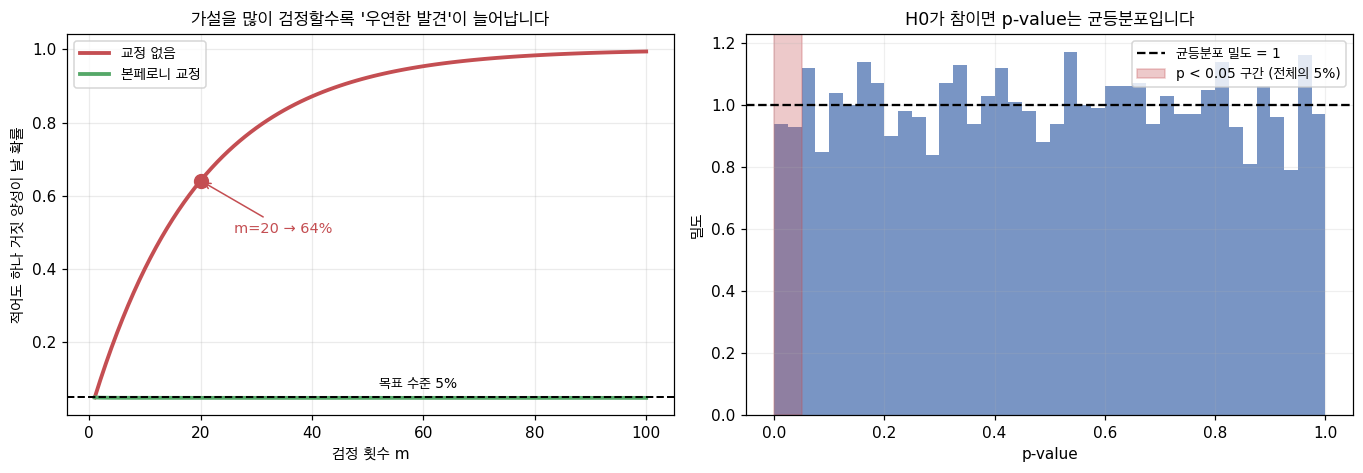

H0가 참일 때 p < 0.05가 나온 비율: 4.67%

오른쪽 그림이 다중 비교 문제의 뿌리입니다.
차이가 전혀 없어도 p-value는 0~1에 고르게 퍼집니다. 그러니 20번 뽑으면 하나쯤은 0.05 아래로 떨어져요.
'유의한 결과를 찾을 때까지 계속 시도하는 것'이 왜 부정직한지가 여기서 보입니다.


In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))

ms = np.arange(1, 101)
ax1.plot(ms, 1 - 0.95 ** ms, lw=2.5, color="#c44e52", label="교정 없음")
ax1.plot(ms, [1 - (1 - 0.05 / m) ** m for m in ms], lw=2.5, color="#55a868",
         label="본페로니 교정")
ax1.axhline(0.05, color="black", ls="--", lw=1.3)
ax1.text(52, 0.075, "목표 수준 5%", fontsize=9)
for m in [20]:
    ax1.plot([m], [1 - 0.95 ** m], "o", ms=9, color="#c44e52")
    ax1.annotate(f"m={m} → {1-0.95**m:.0%}", xy=(m, 1 - 0.95 ** m), xytext=(m + 6, 0.5),
                 fontsize=9.5, color="#c44e52", arrowprops=dict(arrowstyle="->", color="#c44e52"))
ax1.set_xlabel("검정 횟수 m"); ax1.set_ylabel("적어도 하나 거짓 양성이 날 확률")
ax1.set_title("가설을 많이 검정할수록 '우연한 발견'이 늘어납니다", fontsize=11.5)
ax1.legend(fontsize=9.5); ax1.grid(alpha=0.25)

# 귀무가설이 참일 때 p-value는 균등분포입니다 — 그래서 5%가 0.05 아래 떨어집니다
rng = np.random.default_rng(42)
null_ps = []
for _ in range(4000):
    a = rng.normal(0, 1, 30); b = rng.normal(0, 1, 30)
    null_ps.append(welch_ttest(list(a), list(b))[2])
ax2.hist(null_ps, bins=40, color="#4c72b0", alpha=0.75, density=True)
ax2.axhline(1.0, color="black", ls="--", lw=1.5, label="균등분포 밀도 = 1")
ax2.axvspan(0, 0.05, color="#c44e52", alpha=0.3, label="p < 0.05 구간 (전체의 5%)")
ax2.set_xlabel("p-value"); ax2.set_ylabel("밀도")
ax2.set_title("H0가 참이면 p-value는 균등분포입니다", fontsize=11.5)
ax2.legend(fontsize=9); ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f"H0가 참일 때 p < 0.05가 나온 비율: {np.mean(np.array(null_ps) < 0.05)*100:.2f}%")
print("\n오른쪽 그림이 다중 비교 문제의 뿌리입니다.")
print("차이가 전혀 없어도 p-value는 0~1에 고르게 퍼집니다. 그러니 20번 뽑으면 하나쯤은 0.05 아래로 떨어져요.")
print("'유의한 결과를 찾을 때까지 계속 시도하는 것'이 왜 부정직한지가 여기서 보입니다.")

## 🔟 부트스트랩 — 공식 없이 신뢰구간 만들기

지금까지의 검정들은 전부 **분포 가정**을 깔고 있었습니다. t-검정은 정규성을 가정하죠.
그런데 ML 지표 중에는 그런 가정을 하기 곤란한 게 많습니다. AUC, F1, precision@k 같은 것들요.
이들의 표본분포가 정규라고 말할 근거가 없습니다.

**부트스트랩**은 이 문제를 아주 대담한 방법으로 해결합니다.

> **"모집단을 모르겠으면, 내 표본을 모집단이라고 치자."**

### 📐 알고리즘

```
1. 데이터가 n개 있습니다
2. 거기서 n개를 '복원추출'로 뽑습니다
   (어떤 점은 여러 번 뽑히고, 어떤 점은 한 번도 안 뽑힙니다)
3. 그 부트스트랩 표본에서 원하는 통계량을 계산합니다
4. 이걸 B번 반복합니다 (보통 1,000 ~ 10,000)
5. 그렇게 얻은 B개의 통계량 분포가 곧 표본분포의 근사입니다
```

그리고 신뢰구간은 그냥 **백분위수를 자르면** 됩니다.

```
B개의 통계량을 정렬
95% 신뢰구간 = [2.5번째 백분위수, 97.5번째 백분위수]
```

공식도, 자유도도, 정규성 가정도 없습니다. 그냥 재표집하고 세는 거예요.

### 🏭 왜 ML에서 특히 유용한가

- 테스트셋 정확도는 **점 추정치 하나**입니다. 부트스트랩이 거기에 오차 막대를 붙여 줍니다.
- **어떤 통계량에도** 적용됩니다. 중앙값, 두 평균의 비율, 두 모델의 AUC 차이까지.
- 닫힌 형태의 공식이 필요 없습니다.

### 📐 두 모델 비교에 쓰는 법

```
1. 같은 테스트셋에서 A와 B의 예측을 갖고 있습니다
2. 매 반복마다:
   a. 테스트 인덱스를 복원추출로 재표집합니다
   b. 그 위에서 metric_A, metric_B를 계산합니다
   c. diff = metric_B - metric_A 를 저장합니다
3. diff들의 [2.5%, 97.5%] 백분위수가 차이의 95% 신뢰구간입니다
4. 이 구간이 0을 포함하지 않으면 차이가 유의합니다
```

대응표본 t-검정보다 **더 튼튼합니다.** 분포 가정을 아예 하지 않으니까요.

In [21]:
def bootstrap(data, statistic, n_boot=2000, seed=0):
    rng = random.Random(seed)
    n = len(data)
    out = []
    for _ in range(n_boot):
        resample = [data[rng.randrange(n)] for _ in range(n)]
        out.append(statistic(resample))
    return out

def bootstrap_ci(data, statistic, n_boot=2000, conf=0.95, seed=0):
    stats_ = bootstrap(data, statistic, n_boot, seed)
    lo = percentile(stats_, (1 - conf) / 2 * 100)
    hi = percentile(stats_, (1 - (1 - conf) / 2) * 100)
    return lo, hi, stats_

# 1) 평균에 대한 신뢰구간 — t-검정 공식과 비교해 봅니다
rng = np.random.default_rng(51)
sample = list(rng.normal(0.873, 0.05, 200))

lo_b, hi_b, boot_means = bootstrap_ci(sample, mean, n_boot=4000, seed=1)
lo_t, hi_t = confidence_interval(sample)
print("정규 데이터에서 '평균'의 95% 신뢰구간")
print(f"  t-검정 공식: [{lo_t:.5f}, {hi_t:.5f}]  (폭 {hi_t-lo_t:.5f})")
print(f"  부트스트랩 : [{lo_b:.5f}, {hi_b:.5f}]  (폭 {hi_b-lo_b:.5f})")
print("  => 정규 가정이 맞는 상황에서는 둘이 거의 같습니다. 부트스트랩이 손해 보는 게 없습니다.")

# 2) 공식이 없는 통계량 — 중앙값과 P90
print("\n공식을 외울 수 없는 통계량에도 그냥 됩니다")
for name, stat in [("중앙값", median), ("P90", lambda d: percentile(d, 90)),
                   ("IQR", iqr), ("변동계수", lambda d: stdev(d) / mean(d))]:
    lo, hi, _ = bootstrap_ci(sample, stat, n_boot=2000, seed=2)
    print(f"  {name:<8} 추정 {stat(sample):>9.5f}   95% CI [{lo:.5f}, {hi:.5f}]")

정규 데이터에서 '평균'의 95% 신뢰구간
  t-검정 공식: [0.86250, 0.87748]  (폭 0.01499)
  부트스트랩 : [0.86236, 0.87731]  (폭 0.01495)
  => 정규 가정이 맞는 상황에서는 둘이 거의 같습니다. 부트스트랩이 손해 보는 게 없습니다.

공식을 외울 수 없는 통계량에도 그냥 됩니다
  중앙값      추정   0.87101   95% CI [0.85629, 0.87788]
  P90      추정   0.94676   95% CI [0.93382, 0.96202]
  IQR      추정   0.06910   95% CI [0.05720, 0.08082]
  변동계수     추정   0.06177   95% CI [0.05585, 0.06745]


In [22]:
# 3) 🔨 두 모델 비교 — 부트스트랩으로 '차이의 신뢰구간'을 구합니다
rng = np.random.default_rng(52)
N_TEST = 800

# 같은 테스트셋에 대한 두 모델의 정오 여부 (1=맞음). 상관이 있습니다(쉬운 샘플은 둘 다 맞음)
difficulty = rng.random(N_TEST)
correct_a = (rng.random(N_TEST) > difficulty * 0.42).astype(int)
correct_b = (rng.random(N_TEST) > difficulty * 0.36).astype(int)
paired = list(zip(correct_a.tolist(), correct_b.tolist()))

acc_a = mean([a for a, b in paired])
acc_b = mean([b for a, b in paired])
print(f"테스트셋 {N_TEST}개")
print(f"  모델 A 정확도 = {acc_a:.4f}")
print(f"  모델 B 정확도 = {acc_b:.4f}")
print(f"  차이          = {acc_b - acc_a:+.4f}")

diff_stat = lambda pairs: mean([b for a, b in pairs]) - mean([a for a, b in pairs])
lo, hi, boot_diffs = bootstrap_ci(paired, diff_stat, n_boot=4000, seed=3)

print(f"\n부트스트랩 4,000회")
print(f"  차이의 95% 신뢰구간 = [{lo:+.4f}, {hi:+.4f}]")
print(f"  0을 포함하나? {'예 -> 유의하지 않습니다' if lo <= 0 <= hi else '아니오 -> 유의합니다'}")
print(f"  차이가 0보다 큰 부트스트랩 비율 = {np.mean(np.array(boot_diffs) > 0)*100:.1f}%")

acc_lo_a, acc_hi_a, _ = bootstrap_ci([a for a, b in paired], mean, n_boot=2000, seed=4)
acc_lo_b, acc_hi_b, _ = bootstrap_ci([b for a, b in paired], mean, n_boot=2000, seed=5)
print(f"\n각 모델의 정확도 신뢰구간")
print(f"  A: {acc_a:.4f}  95% CI [{acc_lo_a:.4f}, {acc_hi_a:.4f}]")
print(f"  B: {acc_b:.4f}  95% CI [{acc_lo_b:.4f}, {acc_hi_b:.4f}]")
print("\n⚠️ 주의: 두 모델의 신뢰구간이 겹친다고 해서 '차이가 없다'가 아닙니다.")
print("   반드시 '차이 그 자체'의 신뢰구간을 봐야 합니다. 위에서 구한 게 그것입니다.")

테스트셋 800개
  모델 A 정확도 = 0.7788
  모델 B 정확도 = 0.8287
  차이          = +0.0500

부트스트랩 4,000회
  차이의 95% 신뢰구간 = [+0.0150, +0.0863]
  0을 포함하나? 아니오 -> 유의합니다
  차이가 0보다 큰 부트스트랩 비율 = 99.6%

각 모델의 정확도 신뢰구간
  A: 0.7788  95% CI [0.7512, 0.8063]
  B: 0.8287  95% CI [0.8025, 0.8538]

⚠️ 주의: 두 모델의 신뢰구간이 겹친다고 해서 '차이가 없다'가 아닙니다.
   반드시 '차이 그 자체'의 신뢰구간을 봐야 합니다. 위에서 구한 게 그것입니다.


### 🖼️ 그림 8 — 부트스트랩이 실제로 하는 일

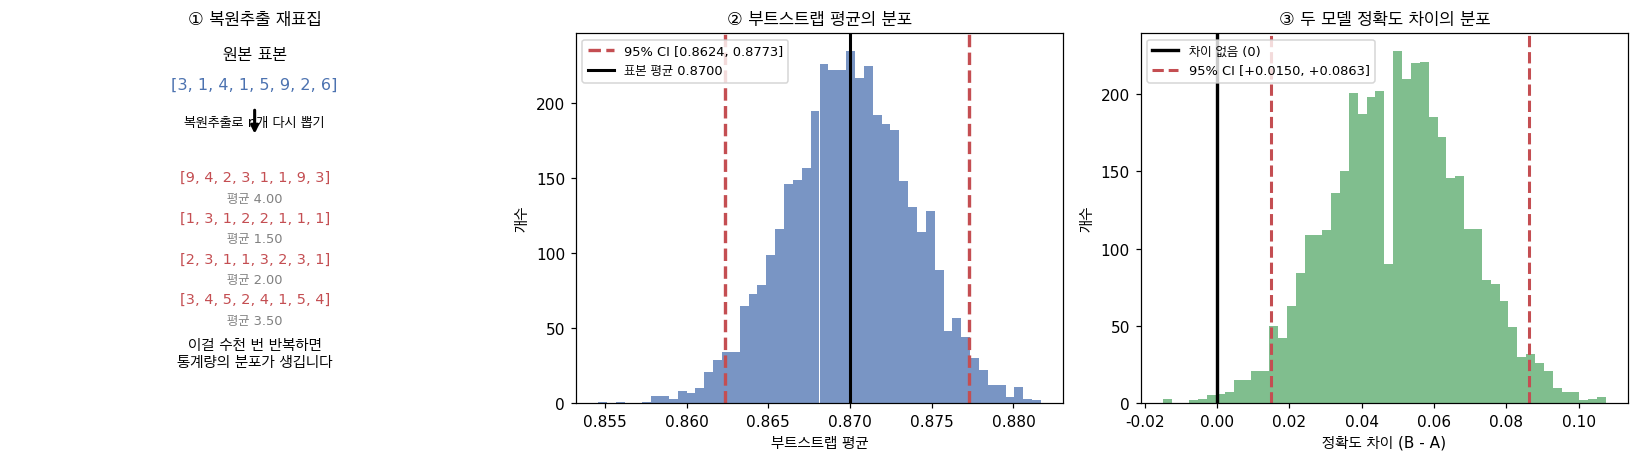

③번 그림이 의사결정에 직접 쓰이는 그림입니다.
분포 전체가 0의 오른쪽에 있으면 'B가 낫다'고 말할 수 있고,
0을 걸치고 있으면 '아직 모른다'가 정직한 결론입니다.


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

# (1) 재표집이란 무엇인가
rng_demo = random.Random(7)
orig = [3, 1, 4, 1, 5, 9, 2, 6]
resamples = [[orig[rng_demo.randrange(len(orig))] for _ in range(len(orig))] for _ in range(4)]
ax = axes[0]
ax.text(0.5, 0.93, "원본 표본", ha="center", fontsize=11, weight="bold", transform=ax.transAxes)
ax.text(0.5, 0.85, str(orig), ha="center", fontsize=10.5, transform=ax.transAxes, color="#4c72b0")
ax.annotate("", xy=(0.5, 0.72), xytext=(0.5, 0.80), xycoords="axes fraction",
            arrowprops=dict(arrowstyle="-|>", lw=2, color="black"))
ax.text(0.5, 0.75, "복원추출로 n개 다시 뽑기", ha="center", fontsize=9, transform=ax.transAxes)
for i, rs in enumerate(resamples):
    ax.text(0.5, 0.6 - i * 0.11, str(rs), ha="center", fontsize=9.5,
            transform=ax.transAxes, color="#c44e52")
    ax.text(0.5, 0.545 - i * 0.11, f"평균 {mean(rs):.2f}", ha="center", fontsize=8.5,
            transform=ax.transAxes, color="gray")
ax.text(0.5, 0.10, "이걸 수천 번 반복하면\n통계량의 분포가 생깁니다", ha="center",
        fontsize=10, transform=ax.transAxes)
ax.axis("off")
ax.set_title("① 복원추출 재표집", fontsize=11.5)

# (2) 부트스트랩 평균 분포와 CI
ax = axes[1]
ax.hist(boot_means, bins=50, color="#4c72b0", alpha=0.75)
ax.axvline(lo_b, color="#c44e52", lw=2.2, ls="--")
ax.axvline(hi_b, color="#c44e52", lw=2.2, ls="--", label=f"95% CI [{lo_b:.4f}, {hi_b:.4f}]")
ax.axvline(mean(sample), color="black", lw=2, label=f"표본 평균 {mean(sample):.4f}")
ax.set_title("② 부트스트랩 평균의 분포", fontsize=11.5)
ax.set_xlabel("부트스트랩 평균"); ax.set_ylabel("개수")
ax.legend(fontsize=8.5)

# (3) 두 모델 차이의 분포
ax = axes[2]
ax.hist(boot_diffs, bins=50, color="#55a868", alpha=0.75)
ax.axvline(0, color="black", lw=2.2, label="차이 없음 (0)")
ax.axvline(lo, color="#c44e52", lw=2, ls="--")
ax.axvline(hi, color="#c44e52", lw=2, ls="--", label=f"95% CI [{lo:+.4f}, {hi:+.4f}]")
ax.set_title("③ 두 모델 정확도 차이의 분포", fontsize=11.5)
ax.set_xlabel("정확도 차이 (B - A)"); ax.set_ylabel("개수")
ax.legend(fontsize=8.5)

plt.tight_layout()
plt.show()

print("③번 그림이 의사결정에 직접 쓰이는 그림입니다.")
print("분포 전체가 0의 오른쪽에 있으면 'B가 낫다'고 말할 수 있고,")
print("0을 걸치고 있으면 '아직 모른다'가 정직한 결론입니다.")

## 1️⃣1️⃣ 모수 vs 비모수 검정

검정은 크게 두 부류로 나뉩니다.

**모수 검정(parametric)** 은 데이터가 특정 분포(보통 정규)를 따른다고 가정합니다.
t-검정, ANOVA, 피어슨 상관이 여기 속해요.

**비모수 검정(non-parametric)** 은 분포 가정을 하지 않습니다.
대신 **값 대신 순위나 부호**를 씁니다.

| 모수 검정 | 대응하는 비모수 검정 |
| --- | --- |
| 독립 t-검정 | Mann-Whitney U |
| 대응 t-검정 | Wilcoxon 부호순위 |
| 피어슨 상관 | 스피어만 ρ |
| ANOVA | Kruskal-Wallis |

### 🏭 그래서 어느 쪽을 써야 할까요

**비모수를 쓰는 게 나은 경우**는 표본이 작으면서(n < 30) 분포가 명백히 비정규일 때,
평점·순위 같은 순서형 데이터일 때, 제거할 수 없는 심한 이상치가 있을 때입니다.

**모수를 쓰는 게 나은 경우**는 표본이 클 때(중심극한정리 덕에 검정통계량이 대략 정규가 됩니다),
데이터가 대체로 대칭이고 극단값이 없을 때입니다. 이때는 **검정력이 더 높아요** — 진짜 차이를 더 잘 잡아냅니다.

> 💡 **ML 실험은 보통 n이 작습니다.** 교차검증 폴드 5개나 10개죠.
> 그래서 t-검정보다 **Wilcoxon 부호순위 검정**이 더 적절한 경우가 생각보다 많습니다.
> 폴드 점수가 정규분포를 따를 이유가 딱히 없거든요.

In [24]:
def mann_whitney_u(xs, ys):
    # 두 그룹을 합쳐 순위를 매긴 뒤, 한 그룹의 순위합으로 U를 계산합니다
    combined = list(xs) + list(ys)
    ranks = rank(combined)
    n1, n2 = len(xs), len(ys)
    r1 = sum(ranks[:n1])
    u1 = r1 - n1 * (n1 + 1) / 2
    u2 = n1 * n2 - u1
    u = min(u1, u2)
    # 정규 근사 (연속성 보정 포함)
    mu = n1 * n2 / 2
    sigma = math.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z = (u - mu + 0.5) / sigma
    return u, 2 * normal_cdf(z)

def wilcoxon_signed_rank(xs, ys):
    # 짝지어진 차이의 '절댓값 순위'에 부호를 붙여 합산합니다
    diffs = [x - y for x, y in zip(xs, ys) if x != y]
    n = len(diffs)
    abs_ranks = rank([abs(d) for d in diffs])
    w_plus = sum(r for d, r in zip(diffs, abs_ranks) if d > 0)
    w_minus = sum(r for d, r in zip(diffs, abs_ranks) if d < 0)
    w = min(w_plus, w_minus)
    mu = n * (n + 1) / 4
    sigma = math.sqrt(n * (n + 1) * (2 * n + 1) / 24)
    z = (w - mu + 0.5) / sigma
    return w, 2 * normal_cdf(z)

print("[상황 1] 정규에 가까운 데이터 — 모수 검정이 더 예민합니다")
rng = np.random.default_rng(61)
a = list(rng.normal(0.85, 0.02, 12))
b = list(rng.normal(0.87, 0.02, 12))
print(f"  Welch t-검정   : p = {welch_ttest(a, b)[2]:.5f}")
print(f"  Mann-Whitney U : p = {mann_whitney_u(a, b)[1]:.5f}")
print(f"  scipy 대조     : t {sps.ttest_ind(a, b, equal_var=False).pvalue:.5f}, "
      f"U {sps.mannwhitneyu(a, b, alternative='two-sided').pvalue:.5f}")

print("\n[상황 2] 이상치가 낀 데이터 — 모수 검정이 무너집니다")
a2 = a[:]
b2 = b[:]
b2[0] = 0.30       # 한 폴드에서 학습이 터졌다고 가정
print(f"  Welch t-검정   : p = {welch_ttest(a2, b2)[2]:.5f}  <- 이상치 하나에 결론이 뒤집혔습니다")
print(f"  Mann-Whitney U : p = {mann_whitney_u(a2, b2)[1]:.5f}  <- 순위만 보니 버팁니다")

print("\n[상황 3] 대응표본 — 7절의 폴드 데이터로")
print(f"  대응 t-검정        : p = {paired_ttest(scores_b, scores_a)[2]:.6f}")
print(f"  Wilcoxon 부호순위  : p = {wilcoxon_signed_rank(scores_b, scores_a)[1]:.6f}")
print(f"  scipy 대조         : {sps.wilcoxon(scores_b, scores_a).pvalue:.6f}")
print("\n  (n=10처럼 작을 때는 정규 근사가 완벽하지 않아 scipy의 정확검정과 조금 다를 수 있습니다)")

[상황 1] 정규에 가까운 데이터 — 모수 검정이 더 예민합니다
  Welch t-검정   : p = 0.00390
  Mann-Whitney U : p = 0.00610
  scipy 대조     : t 0.00390, U 0.00610

[상황 2] 이상치가 낀 데이터 — 모수 검정이 무너집니다
  Welch t-검정   : p = 0.68380  <- 이상치 하나에 결론이 뒤집혔습니다
  Mann-Whitney U : p = 0.03509  <- 순위만 보니 버팁니다

[상황 3] 대응표본 — 7절의 폴드 데이터로
  대응 t-검정        : p = 0.000022
  Wilcoxon 부호순위  : p = 0.005922
  scipy 대조         : 0.001953

  (n=10처럼 작을 때는 정규 근사가 완벽하지 않아 scipy의 정확검정과 조금 다를 수 있습니다)


## 1️⃣2️⃣ 중심극한정리가 실제로 해 주는 일

지금까지 t-검정이며 신뢰구간이며 마음 놓고 썼는데, 사실 그 밑에는 전부 **중심극한정리(CLT)** 가 깔려 있습니다.

CLT는 이렇게 말합니다.

> **원래 분포가 무엇이든, 표본평균의 분포는 n이 커지면 정규분포에 가까워진다.**

$$\bar{X} \sim \text{Normal}\left(\mu,\ \frac{\sigma^2}{n}\right) \quad \text{as } n \to \infty$$

대부분의 경우 n ≥ 30이면 충분하고, 심하게 치우친 분포라면 n ≥ 100쯤 필요합니다.

### 🏭 이게 ML에서 왜 중요한가

1. **집계된 지표에 t-검정과 신뢰구간을 쓸 수 있는 근거**가 됩니다.
2. 개별 폴드 점수는 들쭉날쭉해도 **평균 내면 안정적인 추정치**가 나오는 이유를 설명합니다.
3. **미니배치 경사하강법이 작동하는 이유**이기도 합니다. 배치 평균 그래디언트가 참 그래디언트를 근사하거든요.
   이게 바로 CLT가 현장에서 일하는 모습입니다.
4. **앙상블**이 단일 모델보다 안정적인 것도 같은 원리입니다.

### ⚠️ CLT가 해 주지 *않는* 것

- 데이터 자체를 정규로 만들어 주지 **않습니다.** 정규가 되는 건 **표본평균**입니다. 이걸 헷갈리면 안 돼요.
- 분산이 무한한 두꺼운 꼬리 분포(코시 분포)에는 **적용되지 않습니다.**
- 독립이 아닌 데이터(보정 없는 시계열)에도 **적용되지 않습니다.**

특히 세 번째는 ML에서 자주 위반됩니다. 같은 환자에서 나온 여러 의료 영상,
같은 문서에서 나온 여러 문장 — 이런 건 독립이 아닙니다.
그런데도 독립인 척 검정하면 **표본 크기를 부풀린 셈**이 되어 p-value가 실제보다 작게 나옵니다.

In [25]:
# CLT를 직접 눈으로 확인합니다. 셋 다 정규와는 거리가 먼 분포입니다.
rng = np.random.default_rng(71)
POPS = {
    "지수분포 (심한 오른쪽 꼬리)": lambda size: rng.exponential(1.0, size),
    "균등분포 (완전 평평)":        lambda size: rng.uniform(0, 1, size),
    "베르누이 p=0.15 (이산)":      lambda size: rng.binomial(1, 0.15, size),
}
NS = [1, 2, 5, 30]
REPS = 20000

# 정규분포는 왜도(치우침)와 초과첨도가 둘 다 0입니다. 이 두 값이 0으로 가는지를 봅니다.
print("표본평균 분포의 왜도(skewness) — 정규분포라면 0입니다")
print(f"{'모집단':<28}" + "".join(f"{'n='+str(n):>13}" for n in NS))
print("-" * 80)
sample_means = {}
for name, draw in POPS.items():
    row, cells_ = [], {}
    for n in NS:
        means = draw((REPS, n)).mean(axis=1)
        cells_[n] = means
        row.append(f"{sps.skew(means):>13.4f}")
    sample_means[name] = cells_
    print(f"{name:<28}" + "".join(row))

print("\n=> n=1일 때는 원래 분포 그대로라 왜도가 큽니다. n을 키우면 0으로 수렴합니다.")
print("   이론값도 정확히 알려져 있습니다: 표본평균의 왜도 = (원래 왜도) / √n")
print(f"\n   지수분포의 왜도는 2입니다. 예측값과 실측값을 비교해 보면")
for n in NS:
    pred = 2 / math.sqrt(n)
    obs = sps.skew(sample_means["지수분포 (심한 오른쪽 꼬리)"][n])
    print(f"     n={n:<3} 예측 {pred:.4f}   실측 {obs:.4f}")
print("\n   깔끔하게 맞습니다. 다만 '0에 가까워진다'이지 '0이 된다'가 아니라는 점,")
print("   그래서 심하게 치우친 분포는 n=30에서도 완전히 정규는 아니라는 점을 기억하세요.")

표본평균 분포의 왜도(skewness) — 정규분포라면 0입니다
모집단                                   n=1          n=2          n=5         n=30
--------------------------------------------------------------------------------
지수분포 (심한 오른쪽 꼬리)                   1.9948       1.4101       0.8967       0.3607
균등분포 (완전 평평)                       0.0028       0.0167      -0.0137       0.0274
베르누이 p=0.15 (이산)                   1.9825       1.3977       0.8551       0.3727

=> n=1일 때는 원래 분포 그대로라 왜도가 큽니다. n을 키우면 0으로 수렴합니다.
   이론값도 정확히 알려져 있습니다: 표본평균의 왜도 = (원래 왜도) / √n

   지수분포의 왜도는 2입니다. 예측값과 실측값을 비교해 보면
     n=1   예측 2.0000   실측 1.9948
     n=2   예측 1.4142   실측 1.4101
     n=5   예측 0.8944   실측 0.8967
     n=30  예측 0.3651   실측 0.3607

   깔끔하게 맞습니다. 다만 '0에 가까워진다'이지 '0이 된다'가 아니라는 점,
   그래서 심하게 치우친 분포는 n=30에서도 완전히 정규는 아니라는 점을 기억하세요.


### 🖼️ 그림 9 — 어떤 분포에서 출발하든 평균은 종 모양으로 갑니다

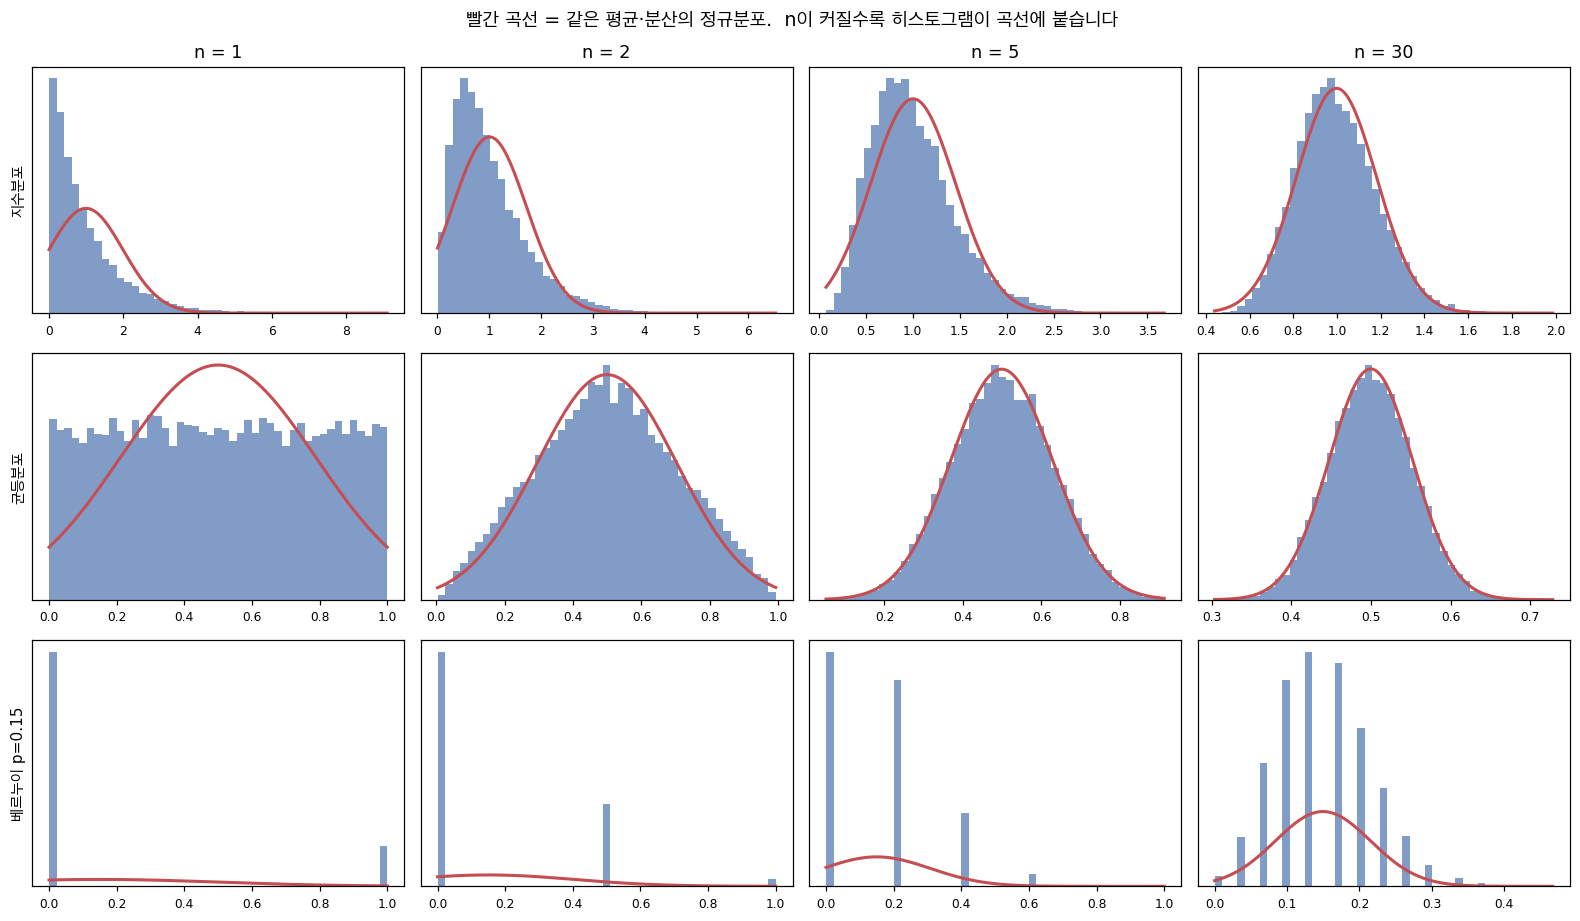

맨 아랫줄을 보세요. 0과 1밖에 없는 베르누이 분포에서 출발했는데도,
30개씩 평균 내면 매끄러운 종 모양이 됩니다.

⚠️ 반례도 확인해 둡시다 — 코시 분포는 분산이 무한이라 CLT가 통하지 않습니다.
   코시 표본평균(n=200)의 범위: [-303.1, 743.6]
   정규였다면 대략 ±0.2 안에 들어와야 합니다. 전혀 수렴하지 않습니다.


In [26]:
fig, axes = plt.subplots(3, 4, figsize=(14.5, 8.5))
for row, (name, cells_) in enumerate(sample_means.items()):
    for col, n in enumerate(NS):
        ax = axes[row][col]
        m = cells_[n]
        ax.hist(m, bins=45, density=True, color="#4c72b0", alpha=0.7)
        # 같은 평균·표준편차의 정규분포를 겹쳐 그립니다
        xs = np.linspace(m.min(), m.max(), 200)
        ax.plot(xs, sps.norm.pdf(xs, m.mean(), m.std()), lw=2, color="#c44e52")
        ax.set_yticks([])
        if row == 0:
            ax.set_title(f"n = {n}", fontsize=11.5)
        if col == 0:
            ax.set_ylabel(name.split(" (")[0], fontsize=10)
        ax.tick_params(labelsize=8)
plt.suptitle("빨간 곡선 = 같은 평균·분산의 정규분포.  n이 커질수록 히스토그램이 곡선에 붙습니다",
             fontsize=12.5)
plt.tight_layout()
plt.show()

print("맨 아랫줄을 보세요. 0과 1밖에 없는 베르누이 분포에서 출발했는데도,")
print("30개씩 평균 내면 매끄러운 종 모양이 됩니다.")
print("\n⚠️ 반례도 확인해 둡시다 — 코시 분포는 분산이 무한이라 CLT가 통하지 않습니다.")
cauchy_means = rng.standard_cauchy((5000, 200)).mean(axis=1)
print(f"   코시 표본평균(n=200)의 범위: [{cauchy_means.min():.1f}, {cauchy_means.max():.1f}]")
print(f"   정규였다면 대략 ±0.2 안에 들어와야 합니다. 전혀 수렴하지 않습니다.")

## 1️⃣3️⃣ 🏭 ML 논문과 리포트에서 반복되는 통계 실수 10가지

원문이 정리한 목록인데, 하나하나가 실제로 자주 봅니다.

| # | 실수 | 왜 문제인가 | 처방 |
| --- | --- | --- | --- |
| 1 | **학습셋에서 평가** | 과적합이 보장됩니다 | 모델이 한 번도 못 본 데이터를 떼어 두세요 |
| 2 | **신뢰구간 없음** | 숫자 하나만으로는 재현·검증이 불가능합니다 | 항상 불확실성을 함께 보고하세요 |
| 3 | **다중 비교 무시** | 50개 설정 중 최고를 고르면 거짓 양성률이 치솟습니다 | 본페로니/FDR 교정 또는 사전 등록 |
| 4 | **통계적 유의성과 실질적 유의성 혼동** | 0.01% 개선에 p=0.001은 의미 없습니다 | 효과 크기를 함께 보고하세요 (8절) |
| 5 | **불균형 데이터에 정확도 사용** | 음성 99% 데이터에서 99% 정확도는 아무것도 학습 안 한 것 | 정밀도·재현율·F1·AUC |
| 6 | **유리한 지표만 선별 보고** | 이기는 지표만 고르는 건 사후 선택입니다 | 관련 지표를 모두 보고하세요 |
| 7 | **train/test 사이 정보 누수** | 분할 전 정규화, 미래 데이터로 과거 예측 | 분할을 먼저, 전처리는 학습셋 통계로만 |
| 8 | **작은 테스트셋에 분산 추정 없음** | 100개로 2% 개선은 잡음입니다 | 부트스트랩으로 신뢰구간을 붙이세요 (10절) |
| 9 | **독립이 아닌데 독립 가정** | 같은 환자의 영상, 같은 문서의 문장은 상관됩니다 | 그룹 단위 분할(GroupKFold), 계층 모형 |
| 10 | **p-해킹** | 유의해질 때까지 검정·부분집합·제외기준을 바꿔 보기 | 분석 계획을 데이터 보기 전에 확정 |

아래 코드로 특히 위험한 **5번(불균형)** 과 **7번(누수)** 을 직접 재현해 보겠습니다.
말로만 들으면 "설마 저런 실수를 하겠어" 싶은데, 숫자로 보면 생각이 달라집니다.

In [27]:
print("=" * 74)
print("실수 5번 — 불균형 데이터에서 정확도를 쓰면 벌어지는 일")
print("=" * 74)
rng = np.random.default_rng(81)
N = 10000
y_true = (rng.random(N) < 0.01).astype(int)      # 양성 1%

# '모델'은 아무것도 안 하고 전부 0이라고 답합니다
y_pred_lazy = np.zeros(N, dtype=int)

def prf(y, p):
    tp = int(((y == 1) & (p == 1)).sum())
    fp = int(((y == 0) & (p == 1)).sum())
    fn = int(((y == 1) & (p == 0)).sum())
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
    return prec, rec, f1

acc = float((y_true == y_pred_lazy).mean())
prec, rec, f1 = prf(y_true, y_pred_lazy)
print(f"  '무조건 음성' 모델의 성능")
print(f"    정확도  = {acc:.4f}  😀 훌륭해 보입니다")
print(f"    정밀도  = {prec:.4f}")
print(f"    재현율  = {rec:.4f}  😱 양성을 하나도 못 찾았습니다")
print(f"    F1      = {f1:.4f}")
print("  => 정확도만 보고하면 '아무 일도 안 하는 모델'이 99% 성능으로 둔갑합니다.")

print("\n" + "=" * 74)
print("실수 7번 — 분할 전에 특징을 고르면 (데이터 누수)")
print("=" * 74)
rng = np.random.default_rng(82)
n_samples, n_features = 60, 400          # 특징이 샘플보다 훨씬 많은 상황
X_all = rng.normal(size=(n_samples, n_features))
y_all = rng.integers(0, 2, n_samples)    # 라벨은 특징과 완전히 무관합니다!

def cv_accuracy(X, y, select_before_split):
    # 아주 단순한 파이프라인: 라벨과 상관 높은 특징 5개 선택 -> 최근접 평균 분류
    folds = np.array_split(np.arange(len(y)), 5)
    accs = []
    if select_before_split:
        corr = np.array([abs(np.corrcoef(X[:, j], y)[0, 1]) for j in range(X.shape[1])])
        top = np.argsort(-corr)[:5]          # ❌ 전체 데이터로 특징을 골랐습니다
    for f in folds:
        tr = np.setdiff1d(np.arange(len(y)), f)
        if not select_before_split:
            corr = np.array([abs(np.corrcoef(X[tr, j], y[tr])[0, 1]) for j in range(X.shape[1])])
            top = np.argsort(-corr)[:5]      # ✅ 학습 폴드만으로 골랐습니다
        c0 = X[tr][y[tr] == 0][:, top].mean(axis=0)
        c1 = X[tr][y[tr] == 1][:, top].mean(axis=0)
        d0 = np.linalg.norm(X[f][:, top] - c0, axis=1)
        d1 = np.linalg.norm(X[f][:, top] - c1, axis=1)
        accs.append(float(((d1 < d0).astype(int) == y[f]).mean()))
    return float(np.mean(accs))

leaky = cv_accuracy(X_all, y_all, select_before_split=True)
clean = cv_accuracy(X_all, y_all, select_before_split=False)
print(f"  라벨은 특징과 아무 관계가 없습니다. 정답은 정확도 0.5여야 합니다.")
print(f"    ❌ 분할 전에 특징 선택 (누수): {leaky:.4f}")
print(f"    ✅ 폴드 안에서 특징 선택     : {clean:.4f}")
print(f"  => 누수만으로 정확도가 {leaky - clean:+.1%} 부풀려졌습니다. 논문 한 편 나올 뻔했습니다.")

실수 5번 — 불균형 데이터에서 정확도를 쓰면 벌어지는 일
  '무조건 음성' 모델의 성능
    정확도  = 0.9887  😀 훌륭해 보입니다
    정밀도  = 0.0000
    재현율  = 0.0000  😱 양성을 하나도 못 찾았습니다
    F1      = 0.0000
  => 정확도만 보고하면 '아무 일도 안 하는 모델'이 99% 성능으로 둔갑합니다.

실수 7번 — 분할 전에 특징을 고르면 (데이터 누수)
  라벨은 특징과 아무 관계가 없습니다. 정답은 정확도 0.5여야 합니다.
    ❌ 분할 전에 특징 선택 (누수): 0.8167
    ✅ 폴드 안에서 특징 선택     : 0.5000
  => 누수만으로 정확도가 +31.7% 부풀려졌습니다. 논문 한 편 나올 뻔했습니다.


## 1️⃣4️⃣ 📝 연습문제 (풀이 포함)

원문의 **Building It** 항목을 연습문제로 바꿔 풀어 봅니다.

1. **기술통계 완성** — 평균·중앙값·최빈값·표준편차·백분위수·IQR을 밑바닥부터 구현하고 NumPy와 대조하기. *(→ 1절에서 완료)*
2. **상관 함수** — 피어슨·스피어만과 공분산 행렬 구현하기. *(→ 2~3절에서 완료)*
3. **가설검정** — 일표본·이표본 t-검정과 카이제곱 검정 구현하기. *(→ 5~6절에서 완료)*
4. **부트스트랩 신뢰구간** — 어떤 통계량에든 적용되는 함수 만들기. *(→ 10절에서 완료)*
5. **A/B 테스트 시뮬레이터** — 데이터를 만들고 검정해서 **1종 오류와 2종 오류**를 직접 세어 보기.
6. **유의성 vs 실질성 데모** — n이 크면 모든 게 유의해진다는 걸 보이기. *(→ 8절에서 완료)*

아래에서는 아직 안 다룬 **5번(오류율과 검정력)** 을 제대로 풀어 봅니다. 이게 사실 제일 재미있는 부분이에요.

### 연습 5 — 1종 오류, 2종 오류, 그리고 검정력

검정 결과는 네 가지 경우로 나뉩니다. 표로 정리하면 명확해요.

| | H0가 실제로 참 (차이 없음) | H0가 실제로 거짓 (차이 있음) |
| --- | --- | --- |
| **H0 기각함** | ❌ **1종 오류** (거짓 양성), 확률 = α | ✅ 정답, 확률 = **검정력** |
| **기각 못함** | ✅ 정답 | ❌ **2종 오류** (거짓 음성), 확률 = β |

- **1종 오류(α)**: 차이가 없는데 있다고 말하는 것. 우리가 α = 0.05로 **직접 정하는** 값입니다.
- **2종 오류(β)**: 차이가 있는데 못 찾는 것. 이건 우리가 정하는 게 아니라 **결정되는** 값입니다.
- **검정력 = 1 − β**: 진짜 차이를 찾아낼 확률. 관례적으로 **0.8 이상**을 목표로 합니다.

검정력은 세 가지에 달려 있습니다: **효과 크기**(클수록 찾기 쉬움),
**표본 크기**(클수록 찾기 쉬움), **α**(느슨할수록 찾기 쉽지만 거짓 양성이 늘어남).

> 🏭 실무에서 가장 흔한 실패는 **검정력이 모자라는 실험**입니다.
> "유의하지 않았다"는 결과가 나왔을 때, 정말 차이가 없어서인지 아니면
> **차이를 발견할 힘이 애초에 없었던 건지**를 구분해야 합니다.

In [28]:
def ab_test_simulator(true_diff, n, sigma=0.02, alpha=0.05, trials=3000, seed=0):
    # 진짜 차이가 true_diff일 때, 검정이 얼마나 자주 '유의'를 외치는지 셉니다
    rng = np.random.default_rng(seed)
    rejections = 0
    for _ in range(trials):
        a = rng.normal(0.85, sigma, n)
        b = rng.normal(0.85 + true_diff, sigma, n)
        _, _, p = welch_ttest(list(a), list(b))
        rejections += (p < alpha)
    return rejections / trials

print("[A] 1종 오류율 — 진짜 차이가 0일 때 '유의'가 나오는 비율")
print("    (α = 0.05로 설정했으니 5% 근처가 나와야 정상입니다)")
print(f"{'표본 크기':>12}{'1종 오류율':>16}")
print("-" * 30)
for n in [20, 50, 200, 1000]:
    rate = ab_test_simulator(0.0, n, trials=3000, seed=91)
    print(f"{n:>12}{rate*100:>15.2f}%")
print("  => n과 무관하게 5% 근처입니다. α는 우리가 '정하는' 값이니 당연합니다.")

print("\n[B] 검정력 — 진짜 차이가 0.01일 때 그걸 찾아내는 비율")
print(f"{'표본 크기':>12}{'검정력':>14}{'2종 오류율 β':>18}{'판정':>14}")
print("-" * 62)
for n in [20, 50, 100, 200, 500]:
    power = ab_test_simulator(0.01, n, trials=3000, seed=92)
    verdict = "✅ 충분" if power >= 0.8 else "⚠️ 부족"
    print(f"{n:>12}{power*100:>13.1f}%{(1-power)*100:>17.1f}%{verdict:>14}")

print("\n  => n=20이면 진짜 있는 차이를 절반도 못 찾습니다.")
print("     이 상황에서 '유의하지 않았다'는 결론은 사실상 아무 정보도 주지 못합니다.")

[A] 1종 오류율 — 진짜 차이가 0일 때 '유의'가 나오는 비율
    (α = 0.05로 설정했으니 5% 근처가 나와야 정상입니다)
       표본 크기          1종 오류율
------------------------------
          20           4.57%
          50           4.97%
         200           5.47%
        1000           4.93%
  => n과 무관하게 5% 근처입니다. α는 우리가 '정하는' 값이니 당연합니다.

[B] 검정력 — 진짜 차이가 0.01일 때 그걸 찾아내는 비율
       표본 크기           검정력          2종 오류율 β            판정
--------------------------------------------------------------
          20         32.0%             68.0%         ⚠️ 부족
          50         69.6%             30.4%         ⚠️ 부족
         100         94.1%              5.9%          ✅ 충분
         200         99.8%              0.2%          ✅ 충분
         500        100.0%              0.0%          ✅ 충분

  => n=20이면 진짜 있는 차이를 절반도 못 찾습니다.
     이 상황에서 '유의하지 않았다'는 결론은 사실상 아무 정보도 주지 못합니다.


### 🖼️ 그림 10 — 검정력 곡선: 실험을 설계할 때 실제로 보는 그림

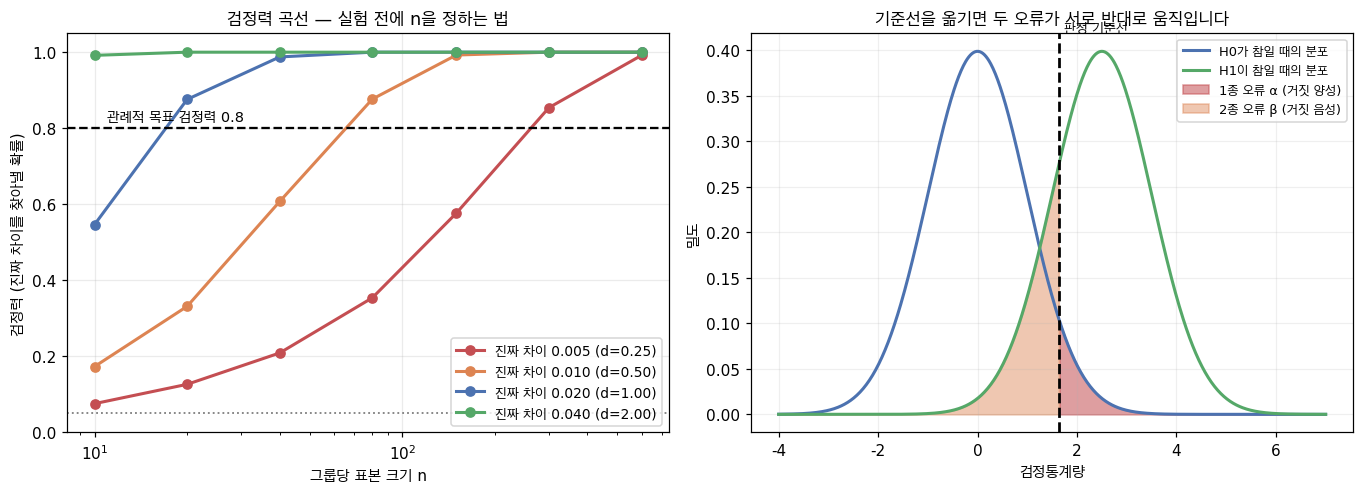

오른쪽 그림의 핵심: 기준선을 오른쪽으로 밀면 거짓 양성(빨강)은 줄지만 거짓 음성(주황)은 늘어납니다.
공짜 점심은 없습니다. 둘 다 줄이는 유일한 방법은 두 분포를 떨어뜨리는 것,
즉 표본을 늘리거나(분포가 좁아짐) 효과 자체가 커지는 것뿐입니다.


In [29]:
effects = [0.005, 0.010, 0.020, 0.040]
ns = [10, 20, 40, 80, 150, 300, 600]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

for e, color in zip(effects, ["#c44e52", "#dd8452", "#4c72b0", "#55a868"]):
    powers = [ab_test_simulator(e, n, trials=1200, seed=100 + n) for n in ns]
    ax1.plot(ns, powers, "o-", lw=2, color=color, label=f"진짜 차이 {e:.3f} (d={e/0.02:.2f})")
ax1.axhline(0.8, color="black", ls="--", lw=1.5)
ax1.text(11, 0.82, "관례적 목표 검정력 0.8", fontsize=9.5)
ax1.axhline(0.05, color="gray", ls=":", lw=1.2)
ax1.set_xscale("log")
ax1.set_xlabel("그룹당 표본 크기 n"); ax1.set_ylabel("검정력 (진짜 차이를 찾아낼 확률)")
ax1.set_title("검정력 곡선 — 실험 전에 n을 정하는 법", fontsize=11.5)
ax1.legend(fontsize=9); ax1.grid(alpha=0.25)
ax1.set_ylim(0, 1.05)

# 1종/2종 오류를 두 분포의 겹침으로 시각화
xs = np.linspace(-4, 7, 700)
h0 = sps.norm.pdf(xs, 0, 1)
h1 = sps.norm.pdf(xs, 2.5, 1)
crit = sps.norm.ppf(0.95)
ax2.plot(xs, h0, lw=2, color="#4c72b0", label="H0가 참일 때의 분포")
ax2.plot(xs, h1, lw=2, color="#55a868", label="H1이 참일 때의 분포")
ax2.fill_between(xs[xs >= crit], h0[xs >= crit], color="#c44e52", alpha=0.55,
                 label="1종 오류 α (거짓 양성)")
ax2.fill_between(xs[xs <= crit], h1[xs <= crit], color="#dd8452", alpha=0.45,
                 label="2종 오류 β (거짓 음성)")
ax2.axvline(crit, color="black", lw=1.8, ls="--")
ax2.text(crit + 0.1, 0.42, "판정 기준선", fontsize=9)
ax2.set_xlabel("검정통계량"); ax2.set_ylabel("밀도")
ax2.set_title("기준선을 옮기면 두 오류가 서로 반대로 움직입니다", fontsize=11.5)
ax2.legend(fontsize=8.5)
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("오른쪽 그림의 핵심: 기준선을 오른쪽으로 밀면 거짓 양성(빨강)은 줄지만 거짓 음성(주황)은 늘어납니다.")
print("공짜 점심은 없습니다. 둘 다 줄이는 유일한 방법은 두 분포를 떨어뜨리는 것,")
print("즉 표본을 늘리거나(분포가 좁아짐) 효과 자체가 커지는 것뿐입니다.")

## 1️⃣5️⃣ 📚 용어 사전 (Key Terms)

| 용어 | 한 줄 정의 |
| --- | --- |
| **평균** | 값의 합을 개수로 나눈 것. 이상치에 취약합니다 |
| **중앙값** | 정렬된 데이터의 가운데 값. 이상치에 강건합니다 |
| **표준편차** | 분산의 제곱근. 원래 단위로 산포를 나타냅니다 |
| **백분위수** | 해당 비율의 데이터가 그 아래에 있는 값 |
| **IQR** | 사분위 범위. Q3 − Q1. 가운데 50%의 폭 |
| **피어슨 상관** | 두 변수의 **선형** 연관성. [−1, 1] |
| **스피어만 상관** | 순위를 이용한 **단조** 연관성 |
| **공분산 행렬** | 모든 특징 쌍의 공분산을 담은 행렬. PCA가 분해하는 대상 |
| **귀무가설** | "효과 없음"이라는 기본 가정. 반증 대상 |
| **p-value** | H0가 참일 때 이만큼 극단적인 데이터가 나올 확률. **H0가 참일 확률이 아닙니다** |
| **신뢰구간** | 같은 절차를 반복하면 그 비율만큼 참값을 포함하는 구간 |
| **t-검정** | 평균 차이를 t분포로 검정. 일표본/이표본(Welch)/대응표본 |
| **카이제곱 검정** | 관측 빈도와 기대 빈도의 불일치를 검정. 범주형용 |
| **효과 크기** | 표본 크기와 무관한 차이의 크기. Cohen's d가 대표 |
| **본페로니 교정** | α를 검정 횟수로 나눠 거짓 양성을 통제 |
| **부트스트랩** | 복원추출 재표집으로 표본분포를 추정. 분포 가정 불필요 |
| **1종 오류** | 거짓 양성. 참인 H0를 기각. 확률 = α |
| **2종 오류** | 거짓 음성. 거짓인 H0를 기각하지 못함. 확률 = β |
| **검정력** | 거짓인 H0를 올바르게 기각할 확률 = 1 − β. 목표 0.8 이상 |
| **중심극한정리** | 표본 크기가 커지면 표본평균의 분포가 정규에 수렴 |
| **모수 검정** | 특정 분포(보통 정규)를 가정. 검정력이 높음 |
| **비모수 검정** | 분포 가정 없음. 순위·부호 기반. 이상치에 강건 |

---

## 🎯 한 문장 정리

> **통계는 "이 차이가 진짜인가?"에 답하는 도구인데,
> 정작 실무에서 더 중요한 건 "그래서 그 차이가 신경 쓸 만한가?"입니다.**

그래서 결과를 보고할 때는 **항상 세 가지를 함께** 적으세요.

| 무엇을 | 무엇을 알려주나 | 없으면 |
| --- | --- | --- |
| **p-value** | 차이가 우연으로 설명되나 | 잡음을 개선이라 부르게 됩니다 |
| **신뢰구간** | 차이가 어느 범위에 있나 | 정밀도를 알 수 없습니다 |
| **효과 크기** | 그 차이가 큰가 | 무의미한 개선에 배포 비용을 씁니다 |

그리고 마지막으로, 실험을 **시작하기 전에** 확인할 것 두 가지입니다.

1. **검정력**이 충분한가? (n이 너무 작으면 애초에 아무것도 발견할 수 없습니다)
2. 검정할 가설을 **미리** 정해 두었는가? (데이터를 본 뒤 찾아 들어가면 p-해킹입니다)

---

## 📖 더 읽을거리

- [Statistical Methods for Comparing Classifiers (Dietterich, 1998)](https://direct.mit.edu/neco/article/10/7/1895/6224) — ML 모델 비교에 어떤 검정을 써야 하는지 다룬 고전
- [The ASA Statement on p-Values (Wasserstein & Lazar, 2016)](https://www.tandfonline.com/doi/full/10.1080/00031305.2016.1154108) — 미국통계학회가 직접 낸 p-value 사용 지침
- [An Introduction to the Bootstrap (Efron & Tibshirani)](https://www.routledge.com/An-Introduction-to-the-Bootstrap/Efron-Tibshirani/p/book/9780412042317) — 부트스트랩의 정본
- [scipy.stats 문서](https://docs.scipy.org/doc/scipy/reference/stats.html) — 이번에 직접 만든 검정들의 프로덕션 버전
- [Statistical Rethinking (McElreath)](https://xcelab.net/rm/) — 베이지안 관점에서 다시 보는 통계. 강의 영상이 특히 좋습니다